# Métaheuristiques à population

CSI 4106 - Automne 2024

Marcel Turcotte  
Version: nov. 17, 2024 11h54

# Préambule

## Citation du jour

[Leland
McInnes](https://www.linkedin.com/in/leland-mcinnes-406233103/?originalSubdomain=ca)
est un chercheur en science des données à l’[Institut Tutte de
Mathématiques et de
Calcul](https://www.cse-cst.gc.ca/fr/mission/recherche-cse/institut-tutte-mathematiques-calcul)
(TIMC) à Ottawa. Le TIMC est un institut de recherche gouvernemental
dédié aux mathématiques fondamentales et à l’informatique. McInnes est
reconnu pour avoir développé
[UMAP](https://umap-learn.readthedocs.io/en/latest/), une technique
avancée de réduction de dimension, et
[HDBSCAN](https://github.com/scikit-learn-contrib/hdbscan), un
algorithme de regroupement populaire intégré à
[scikit-learn](https://scikit-learn.org/stable/).

Cette publication met en lumière l’application de ces technologies dans
la visualisation de publications issues d’[arXiv](https://arxiv.org).

## Objectifs d’apprentissage

-   **Comprendre** la définition et l’objectif des métaheuristiques dans
    les problèmes d’optimisation.
-   **Apprendre** les principes et les composants des algorithmes
    génétiques (AG).
-   **Assimiler** les détails de mise en œuvre des AG, y compris le
    codage, la sélection, le croisement, la mutation et l’évaluation de
    la fitness.
-   **Appliquer** les AG pour résoudre le problème du sac à dos 0/1 à
    l’aide d’exemples pratiques en Python.
-   **Reconnaître** les différents schémas de codage et méthodes de
    sélection dans les AG.

**Voir aussi** : [cahier Jupyter associé](knapsack).

# Introduction

## Métaheuristiques

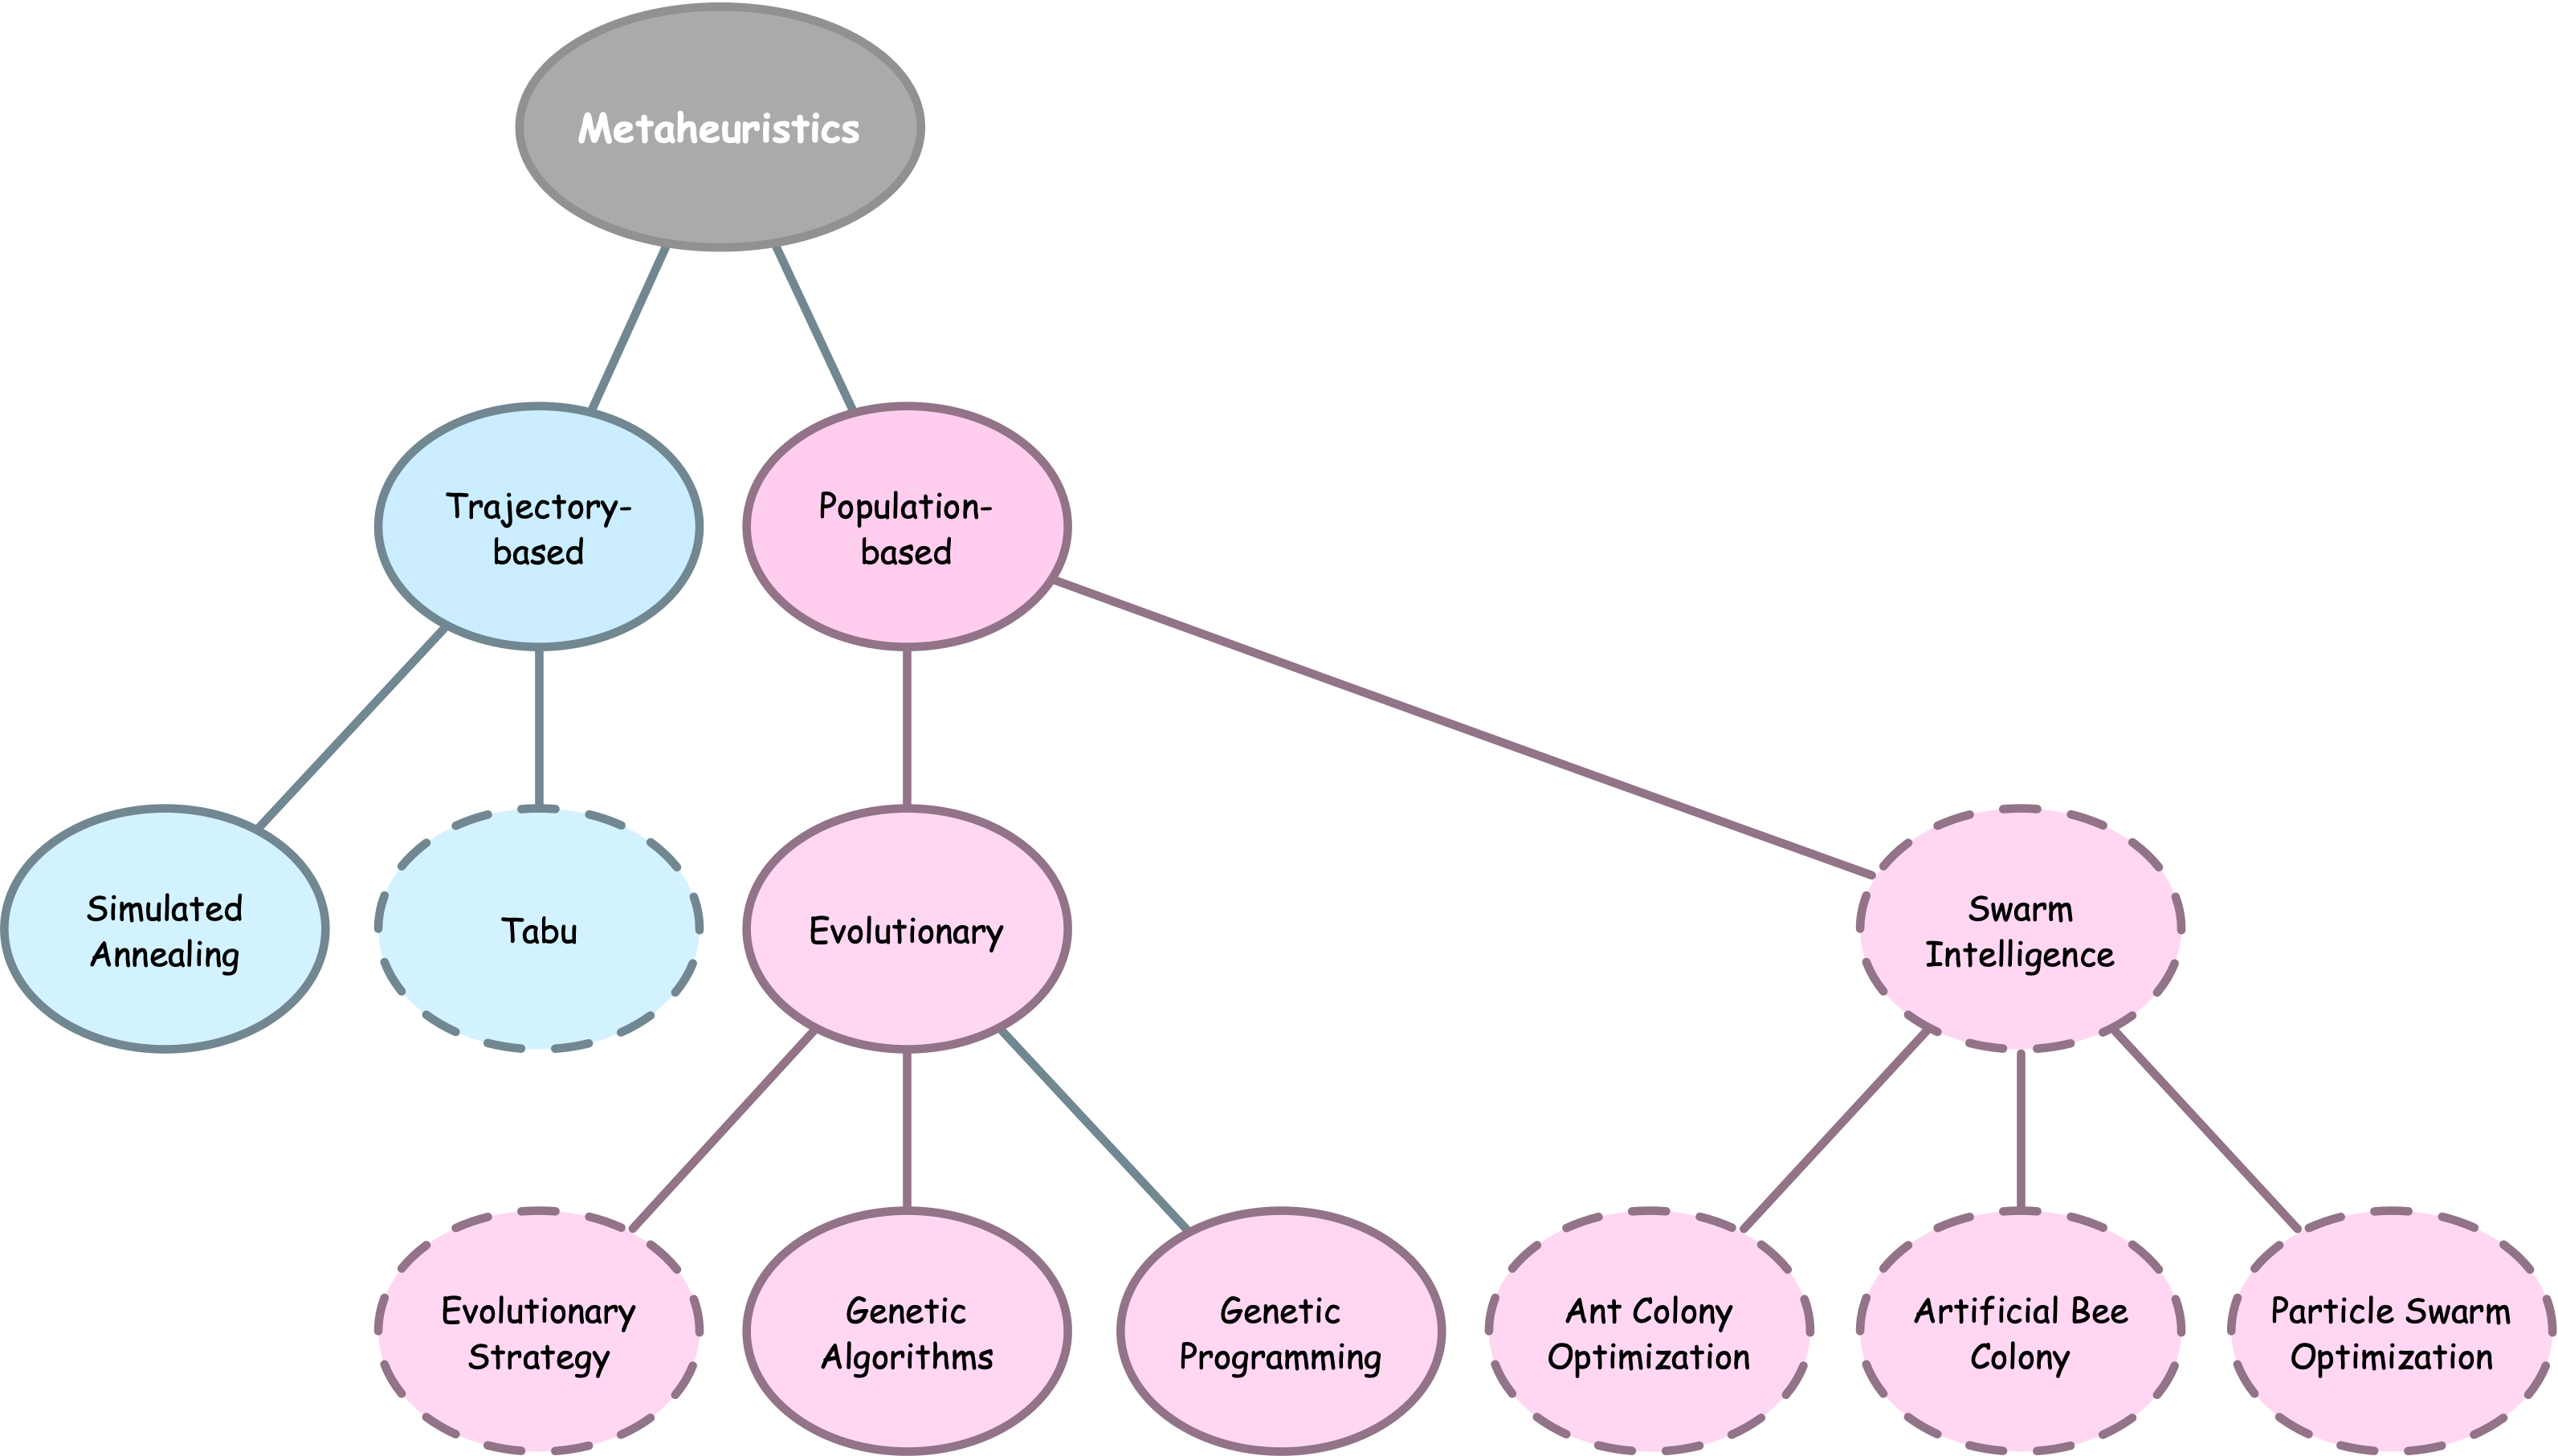

**Le recuit simulé** (*simulated annealing*) s’inspire des principes de
la **physique**. En revanche, nous explorons ici une stratégie inspirée
de la **biologie**.

## Définition

> ** (Gil-Rios et al. 2021)**
>
> Les **métaheuristiques** sont des procédures ou heuristiques de haut
> niveau conçues pour **guider la recherche** de solutions dans des
> problèmes d’optimisation avec des **espaces de solutions vastes**,
> visant à trouver de bonnes solutions plus efficacement que les
> méthodes traditionnelles.

Les métaheuristiques équilibrent **l’exploitation** et **l’exploration**
pour **éviter les optima locaux**, incorporant souvent **l’aléatoire**,
**la mémoire** ou des mécanismes **adaptatifs**.

Elles sont adaptables à des **problèmes d’optimisation divers**.

## Définition

Un **algorithme génétique (AG)** est une technique d’optimisation
évolutionnaire qui utilise une **population de solutions candidates**,
les faisant évoluer par **sélection**, **croisement** et **mutation**
pour s’améliorer de manière itérative vers une solution “optimale”.

------------------------------------------------------------------------

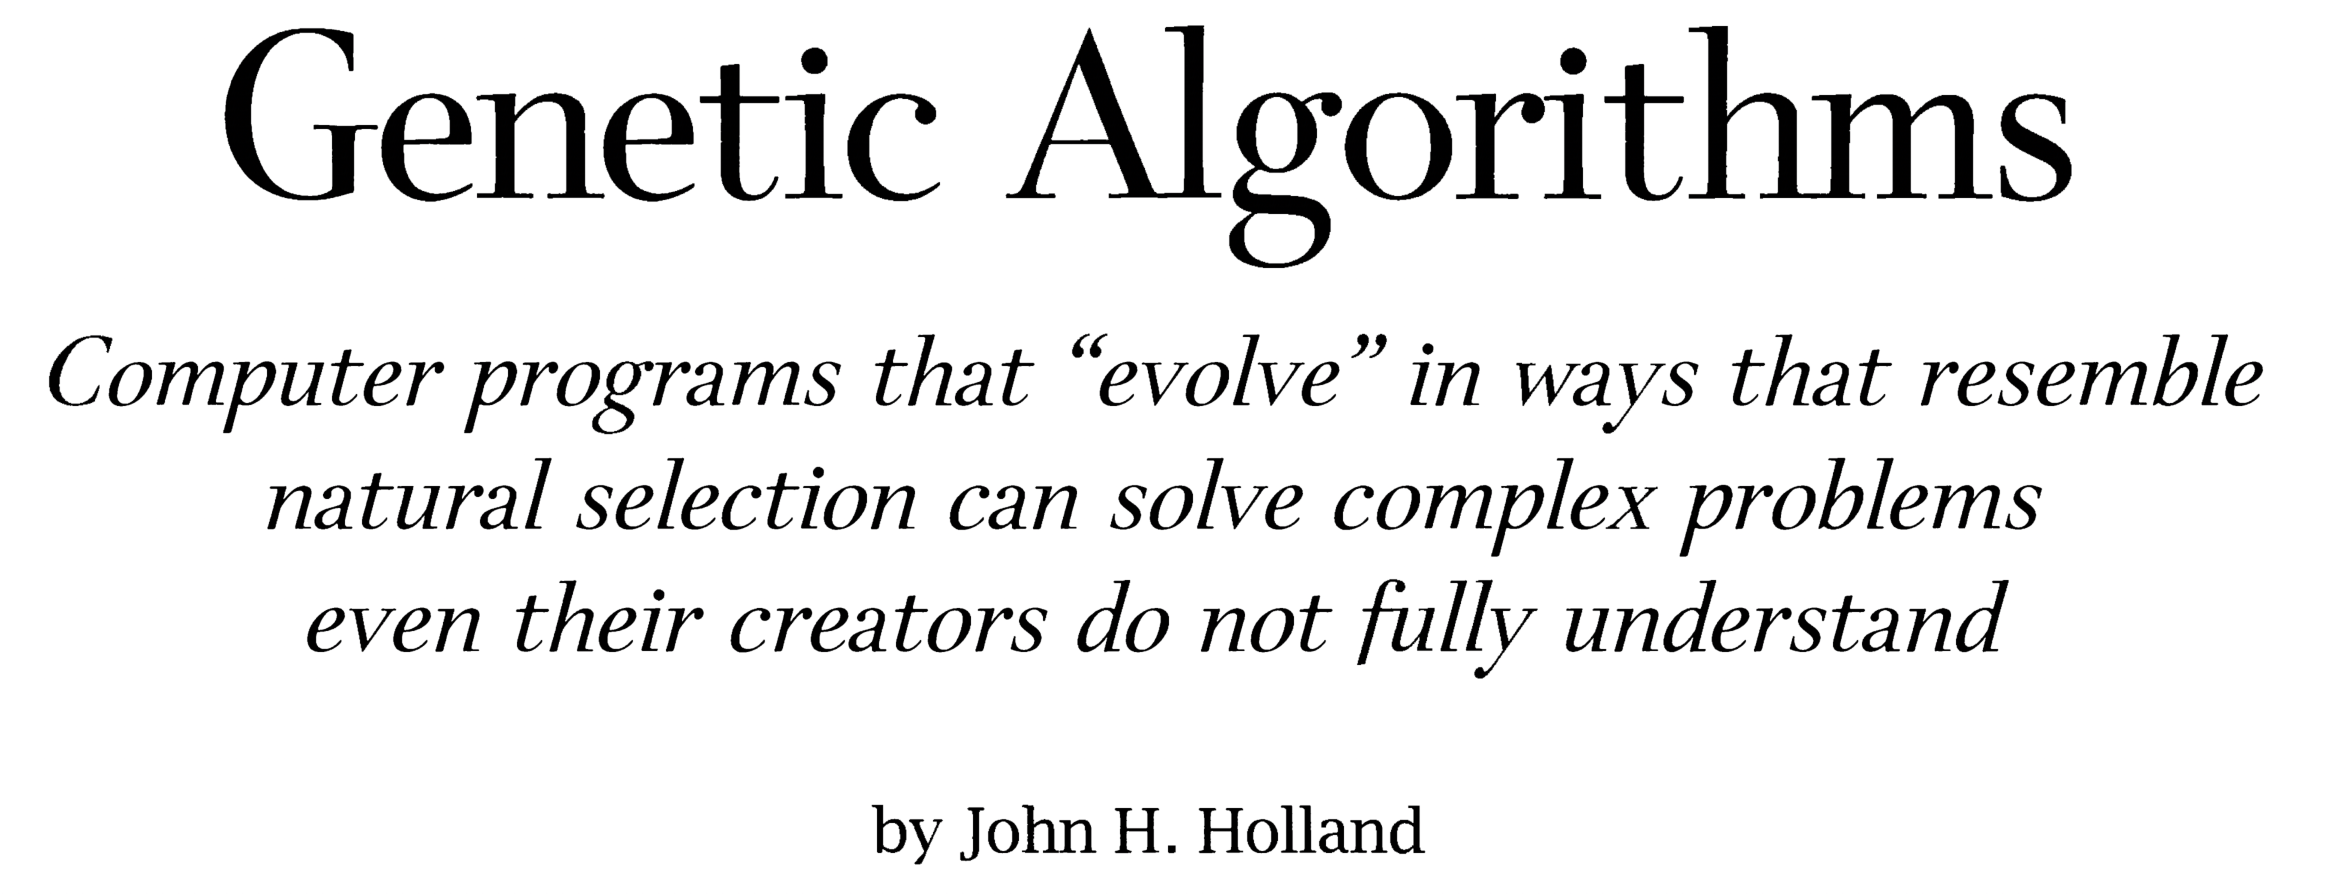

Holland (1992), Holland (1973)

## Tendances en IA

## Applications

-   **Optimisation** : Résolution de problèmes complexes d’ingénierie,
    de logistique et de planification.
-   **Apprentissage automatique** : Sélection de caractéristiques,
    réglage des hyperparamètres et évolution des architectures de
    réseaux neuronaux.
-   **Robotique** : Planification des trajectoires, optimisation des
    capteurs, développement de stratégies de contrôle et conception de
    robots[1].

## Applications (suite)

![](https://media.springernature.com/full/springer-static/cover-hires/book/978-3-030-70542-8?as=webp.png)

Oliva, Houssein, et Hinojosa (2021)

[Springer
Link](https://link.springer.com/book/10.1007/978-3-030-70542-8)

![](https://media.springernature.com/full/springer-static/cover-hires/book/978-981-19-3888-7?as=webp.png)

Eddaly, Jarboui, et Siarry (2023)

[Springer
Link](https://link.springer.com/book/10.1007/978-981-19-3888-7)

Saviez-vous que vous pouvez accéder gratuitement à l’ensemble de la
collection de livres de Springer ? En utilisant un appareil connecté à
une adresse IP de l’Université d’Ottawa et en visitant [Springer
Link](https://link.springer.com), vous avez la possibilité de
télécharger des livres au format PDF ou EPUB.

## De la biologie aux AGs

> ** (Mayr 1982, 481)**
>
> Il n’y a probablement pas de concept plus **original**, plus
> **complexe** et plus **audacieux** dans l’histoire des idées que
> l’explication mécaniste de Darwin sur l’adaptation.

> ** (Dennett 1995)**
>
> Si je devais donner un prix pour **la meilleure idée que quelqu’un ait
> jamais eue**, je le donnerais à Darwin, devant Newton, Einstein et
> tous les autres.

## Définition

> ** (Gregory 2009)**
>
> La **sélection naturelle** est une **différence non aléatoire dans la
> production reproductive parmi des entités réplicantes**, souvent due
> indirectement à des différences de survie dans un environnement
> particulier, **conduisant à une augmentation de la proportion de
> caractéristiques héréditaires bénéfiques** au sein d’une population
> d’une génération à l’autre.

L’**évolution** est un processus d’optimisation **adaptatif**.

# Composantes

## AG de base

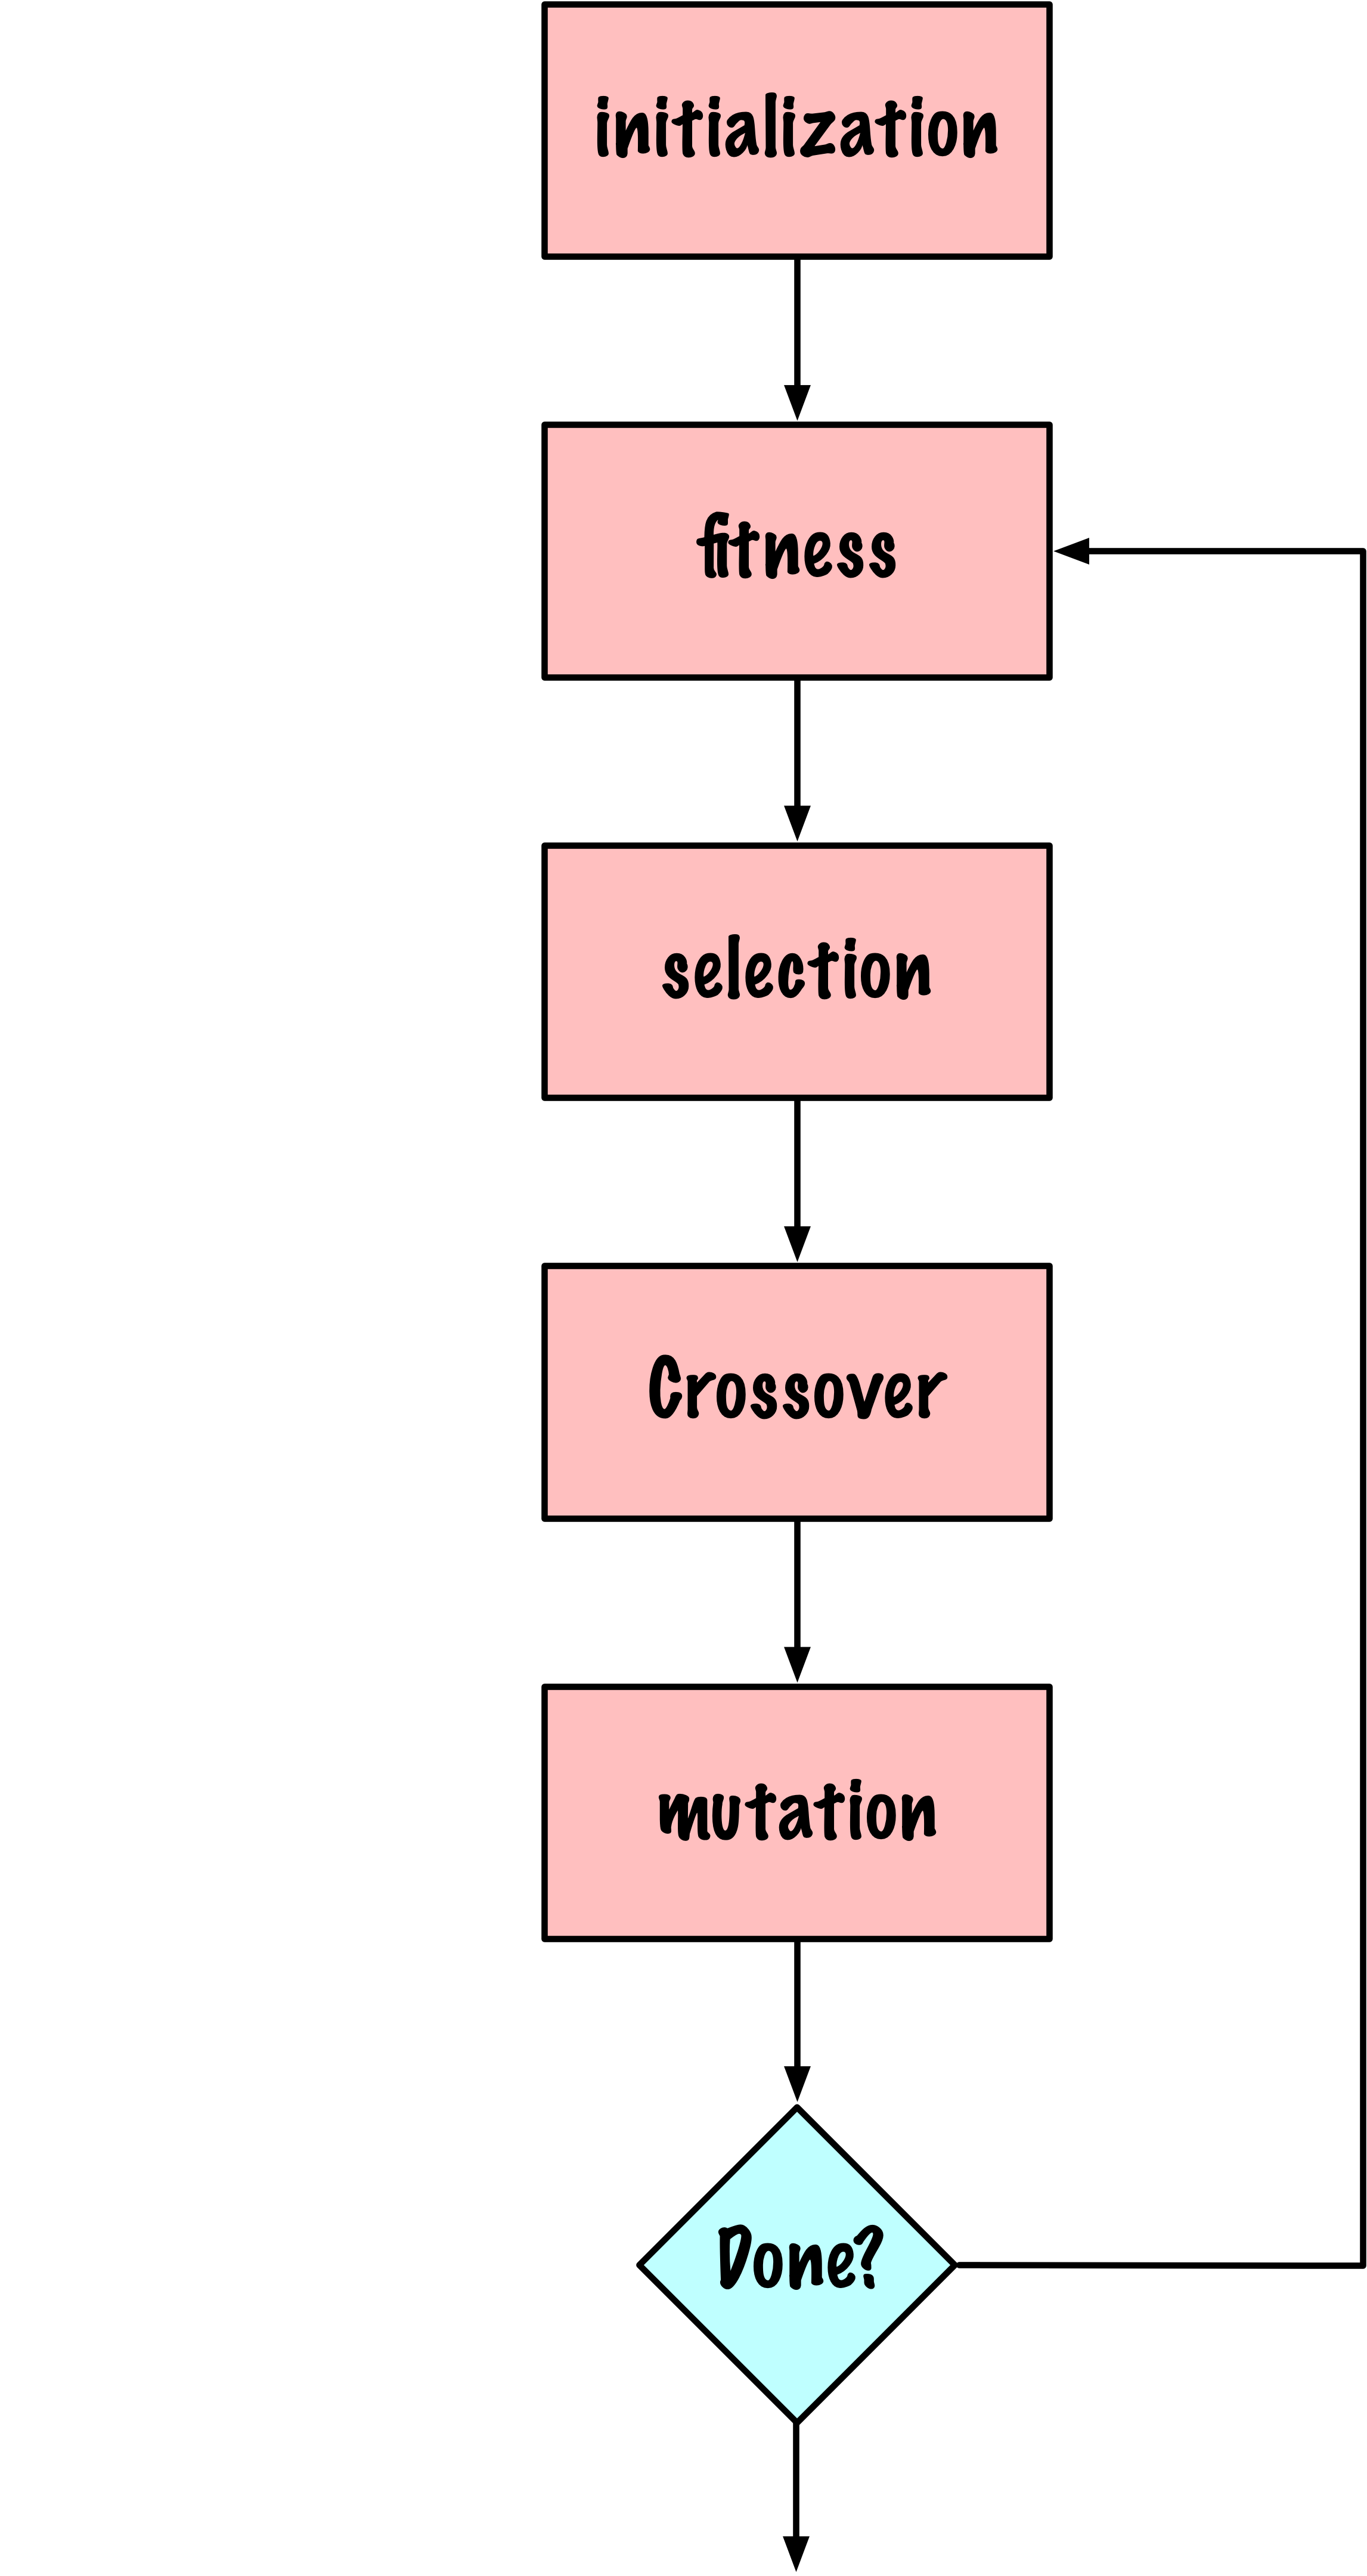

1.  Initialiser la **population**
2.  Calculer l’**aptitude** (fitness)
3.  Sélectionner les **individus** (chromosomes)
4.  **Croisement**
5.  **Mutation**
6.  Si non terminé, **retourner** à l’étape 2

Dans ce contexte, le terme **population** désigne un ensemble de
solutions ou d’états candidats.

## Choix

-   Comment **coder** une solution ou un état candidat ?
-   Comment **sélectionner** les solutions candidates ?
-   Comment définir l’opérateur de **croisement** ?
-   Comment définir l’opérateur de **mutation** ?
-   Comment calculer l’**aptitude** (fitness) ?

## Problème

**Problème du sac à dos 0/1** : Étant donné des objets avec des
**poids** et des **valeurs** définis, l’objectif est de **maximiser la
valeur totale** en sélectionnant des objets pour un sac à dos sans
dépasser une **capacité fixe**. Chaque objet doit être entièrement
**inclus (1)** ou **exclu (0)**.

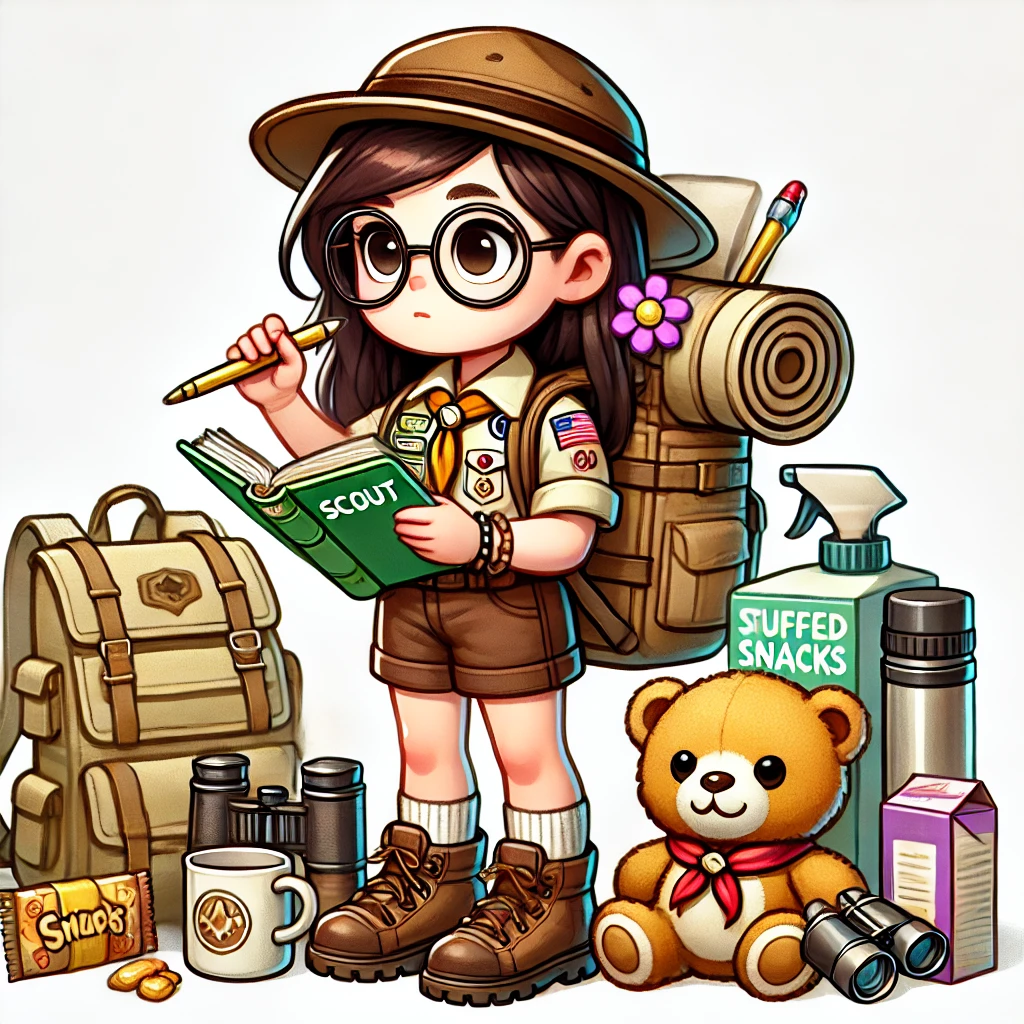

**Attribution** : Généré par DALL-E, via ChatGPT (GPT-4), OpenAI, 10
novembre 2024.

Ce problème est NP-complet et souvent résolu à l’aide de la
programmation dynamique pour obtenir des solutions optimales dans un
délai raisonnable.

L’image ci-dessus a été générée à partir de la description suivante :
“Illustrer une scout fille en dessin animé portant des lunettes, vêtue
d’un uniforme de scout avec des shorts marrons et des bottes de
randonnée. Elle tient un carnet dans une main et un crayon dans l’autre,
avec un grand sac à dos fixé à son dos. Devant elle, afficher une
variété d’objets qu’elle pourrait choisir pour remplir son sac. Ces
objets doivent inclure une pile de livres, une peluche, une tasse, des
collations assorties et une paire de jumelles. La scène doit évoquer une
prise de décision et l’exploration.”

## Problème (suite)

$$
\begin{aligned}
& \text { maximiser } \sum_{i=1}^n x_i \cdot v_i  \\
& \text { sujet à } \sum_{i=1}^n x_i \cdot w_i  \leq W \text { et } x_i \in\{0,1\} .
\end{aligned}
$$

où $W$ représente le **poids maximal fixe**, et $x_i$ est une variable
binaire indiquant si l’objet $i$ est **inclus (1)** ou **exclu (0)**.

## Applications

1.  **Finance et investissement** : Dans l’optimisation de portefeuille,
    où chaque actif a un risque (analogue au poids) et un rendement
    attendu (valeur), le cadre du sac à dos aide à sélectionner un
    ensemble d’actifs qui maximise le rendement sans dépasser un seuil
    de risque.

2.  **Allocation des ressources** : Couramment utilisé dans la gestion
    de projets, où les ressources (budget, personnel, temps) doivent
    être allouées à des projets ou des tâches pour maximiser la valeur
    totale, en tenant compte de la disponibilité limitée.

3.  **Chaîne d’approvisionnement et logistique** : Utilisé pour
    maximiser la valeur des biens transportés dans les limites de poids
    ou de volume des véhicules. Il peut également être appliqué au
    stockage en entrepôt, où l’espace est limité, et les articles de
    grande valeur sont prioritaires.

4.  **Placement publicitaire et marketing** : Utilisé dans la publicité
    numérique pour sélectionner la combinaison la plus rentable
    d’annonces à afficher dans un espace limité (par exemple, espace
    publicitaire sur un site Web ou une application), maximisant ainsi
    les revenus dans le cadre des contraintes de taille ou d’affichage.

## Algorithmes gloutons

> ** (Skiena 2008, 192)**
>
> Les **algorithmes gloutons** (*greedy*) prennent la décision de ce
> qu’il faut faire ensuite en sélectionnant la **meilleure option
> locale** parmi toutes les options disponibles **sans** tenir compte de
> la structure globale.

## Données

[1] Cette approche a permis le développement de formes et de stratégies
de contrôle de robots **uniques**, parfois **inattendues**, qui sont
**bien adaptées à des tâches ou environnements spécifiques**, surpassant
souvent les conceptions traditionnelles et humaines en termes
d’**adaptabilité** et de **robustesse**.

In [2]:
import numpy as np

# Données d'exemple

values = np.array([
    360, 83, 59, 130, 431, 67, 230, 52, 93, 125, 670, 892, 600, 38, 48, 147,
    78, 256, 63, 17, 120, 164, 432, 35, 92, 110, 22, 42, 50, 323, 514, 28,
    87, 73, 78, 15, 26, 78, 210, 36, 85, 189, 274, 43, 33, 10, 19, 389, 276,
    312])

weights = np.array([
    7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0,
    42, 47, 52, 32, 26, 48, 55, 6, 29, 84, 2, 4, 18, 56, 7, 29, 93, 44, 71,
    3, 86, 66, 31, 65, 0, 79, 20, 65, 52, 13])

capacity = 850

Données provenant de [Google
OR-Tools](https://developers.google.com/optimization/pack/knapsack).

## Ordre croissant des poids

In [3]:
def greedy_knapsack_weight(weights, values, capacity):

    num_items = len(weights)

    # Créer une liste d'éléments avec leurs valeurs et indices originaux
    items = list(zip(weights, values, range(num_items)))

    # Trier les éléments par poids en ordre croissant
    items.sort()
    
    total_weight, total_value = 0, 0
    solution = np.zeros(num_items, dtype=int)
    
    # Sélectionner les éléments selon l'ordre trié
    for w, v, idx in items:
        if total_weight + w <= capacity:
            solution[idx] = 1
            total_weight += w
            total_value += v
        else:
            break  # Ignorer les éléments qui dépassent la capacité
    
    return solution, total_value, total_weight

Cette stratégie est-elle **pertinente** ?

-   Quelle est la complexité temporelle de cette méthode ?
    -   $\mathcal{O}(n \log n)$ en raison du tri.
-   Cette stratégie est-elle pertinente ?
    -   Elle néglige la valeur, facteur critique pour l’optimisation.

## `greedy_knapsack_weight`

In [4]:
solution, total_value, total_weight = greedy_knapsack_weight(weights, values, capacity)

print(f"Solution : {solution}")
print(f"Valeur : {total_value}")
print(f"Poids : {total_weight}")

Solution : [1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 0 0 1 0 1 0 1 0 1 1]
Valeur : 5891
Poids : 817

## Ordre décroissant des valeurs

In [5]:
def greedy_knapsack_value(weights, values, capacity):

    num_items = len(weights)

    # Créer une liste d'éléments avec leurs valeurs et indices originaux
    items = list(zip(values, weights, range(num_items)))

    # Trier les éléments par valeur en ordre décroissant
    items.sort(reverse=True)
    
    total_weight = 0
    total_value = 0
    solution = np.zeros(num_items, dtype=int)
    
    # Sélectionner les éléments selon l'ordre trié
    for v, w, idx in items:
        if total_weight + w <= capacity:
            solution[idx] = 1
            total_weight += w
            total_value += v
    
    return solution, total_value, total_weight

-   Quelle est la complexité temporelle de cette méthode ?
    -   $\mathcal{O}(n \log n)$ en raison du tri.
-   Cette stratégie est-elle pertinente ?
    -   Elle met l’accent sur la maximisation de la valeur mais ne
        garantit pas une solution optimale.

## `greedy_knapsack_value`

In [6]:
solution, total_value, total_weight = greedy_knapsack_value(weights, values, capacity)

print(f"Solution : {solution}")
print(f"Valeur : {total_value}")
print(f"Poids : {total_weight}")

Solution : [1 1 0 1 1 0 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Valeur : 7339
Poids : 849

# Implémentation de l’AG

## Encodage

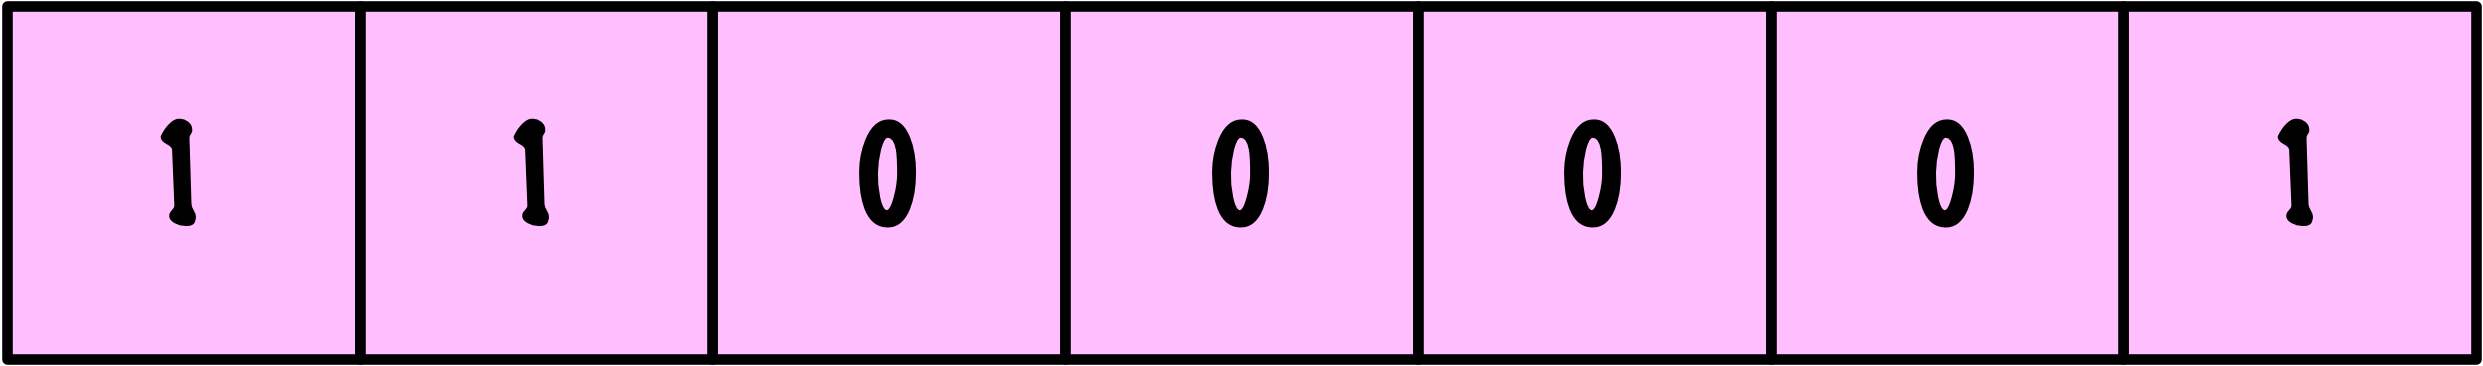

La représentation la **plus simple** pour chaque **chromosome**
(**état**) est un tableau de taille $n$, où $n$ représente le nombre
d’objets. Chaque élément $i$ du tableau indique si l’objet $i$ est
**inclus (1)** ou **exclu (0)**.

## Population

In [7]:
def initialize_population(pop_size, num_items):

    """
    Initialiser la population avec des chaînes binaires aléatoires.

    Args:
        pop_size (int): Nombre d'individus dans la population.
        num_items (int): Nombre d'objets dans le problème du sac à dos.

    Returns:
        np.ndarray: Population initialisée.
    """

    return np.random.randint(2, size=(pop_size, num_items))

Comment choisir la **taille de la population (nombre
d’individus/chromosomes)** ?

**Spécificité du problème** : Ajustez la taille de la population en
fonction de la complexité du problème. Les problèmes plus complexes
peuvent nécessiter une population plus grande pour explorer efficacement
l’espace de solutions.

**Ressources disponibles** : Tenez compte des ressources informatiques
disponibles, car une population plus grande augmente les besoins en
mémoire et en temps de calcul.

**Équilibre entre diversité et convergence** : Une plus grande
population peut maintenir une plus grande diversité génétique, ce qui
aide à éviter les optima locaux, mais peut également ralentir la
convergence. Trouvez un équilibre adapté à votre problème.

**Lignes directrices** : Pour de nombreux problèmes, une règle empirique
consiste à commencer avec une taille de population entre 50 et 100, puis
ajuster en fonction des performances observées.

**Approches adaptatives** : Envisagez d’utiliser des méthodes
adaptatives qui ajustent dynamiquement la taille de la population en
fonction des progrès de l’algorithme.

## Population

La méthode proposée pour initialiser la population présente un
**problème**.

Pouvez-vous identifier *ce qu’il est* ?

La population initiale est générée entièrement de manière aléatoire sans
prendre en compte la faisabilité.

Cela peut entraîner la génération de la plupart des individus non
réalisables (dépassant la capacité), ralentissant ainsi la convergence.

**Suggestion** : Introduire une vérification de faisabilité lors de
l’initialisation ou générer des solutions initiales plus susceptibles
d’être réalisables.

## Aptitude

In [8]:
def evaluate_fitness(population, weights, values, capacity, penalty_factor=10):

    total_weights = np.dot(population, weights)

    total_values = np.dot(population, values)

    penalties = penalty_factor * np.maximum(0, total_weights - capacity)

    fitness = total_values - penalties

    return fitness

Pouvez-vous identifier un **problème** potentiel avec cette fonction
d’aptitude ?

Tout d’abord, notez l’utilisation extensive de `numpy`. Le poids total
de chaque chromosome de notre population est calculé en une seule
expression. Il en va de même pour les valeurs totales.

La fonction d’aptitude applique une stratégie de pénalisation
progressive en déduisant une pénalité proportionnelle à l’excès de
poids, distinguant ainsi les solutions qui dépassent la limite de poids.

On pourrait également attribuer une valeur d’aptitude nulle à toute
solution qui dépasse la capacité du sac à dos. Cependant, cette
pénalisation stricte pourrait conduire une grande partie, voire
l’ensemble, de la population à une aptitude nulle, en particulier dans
les générations initiales. Cette situation pose des défis pour les
mécanismes de sélection, tels que la roulette, qui s’appuient sur des
valeurs d’aptitude non nulles pour calculer les probabilités de
sélection, entraînant potentiellement des erreurs de division par zéro.

La stratégie proposée, qui applique des pénalités aux solutions non
valides, peut amener l’algorithme génétique à générer des solutions non
réalisables. Ces cas nécessitent une gestion externe, comme le
redémarrage de l’algorithme génétique chaque fois qu’une solution non
réalisable est rencontrée.

## Sélection par roulette

La **sélection par roulette** est une méthode stochastique où la
probabilité de sélectionner un individu est proportionnelle à son
aptitude par rapport au reste de la population.

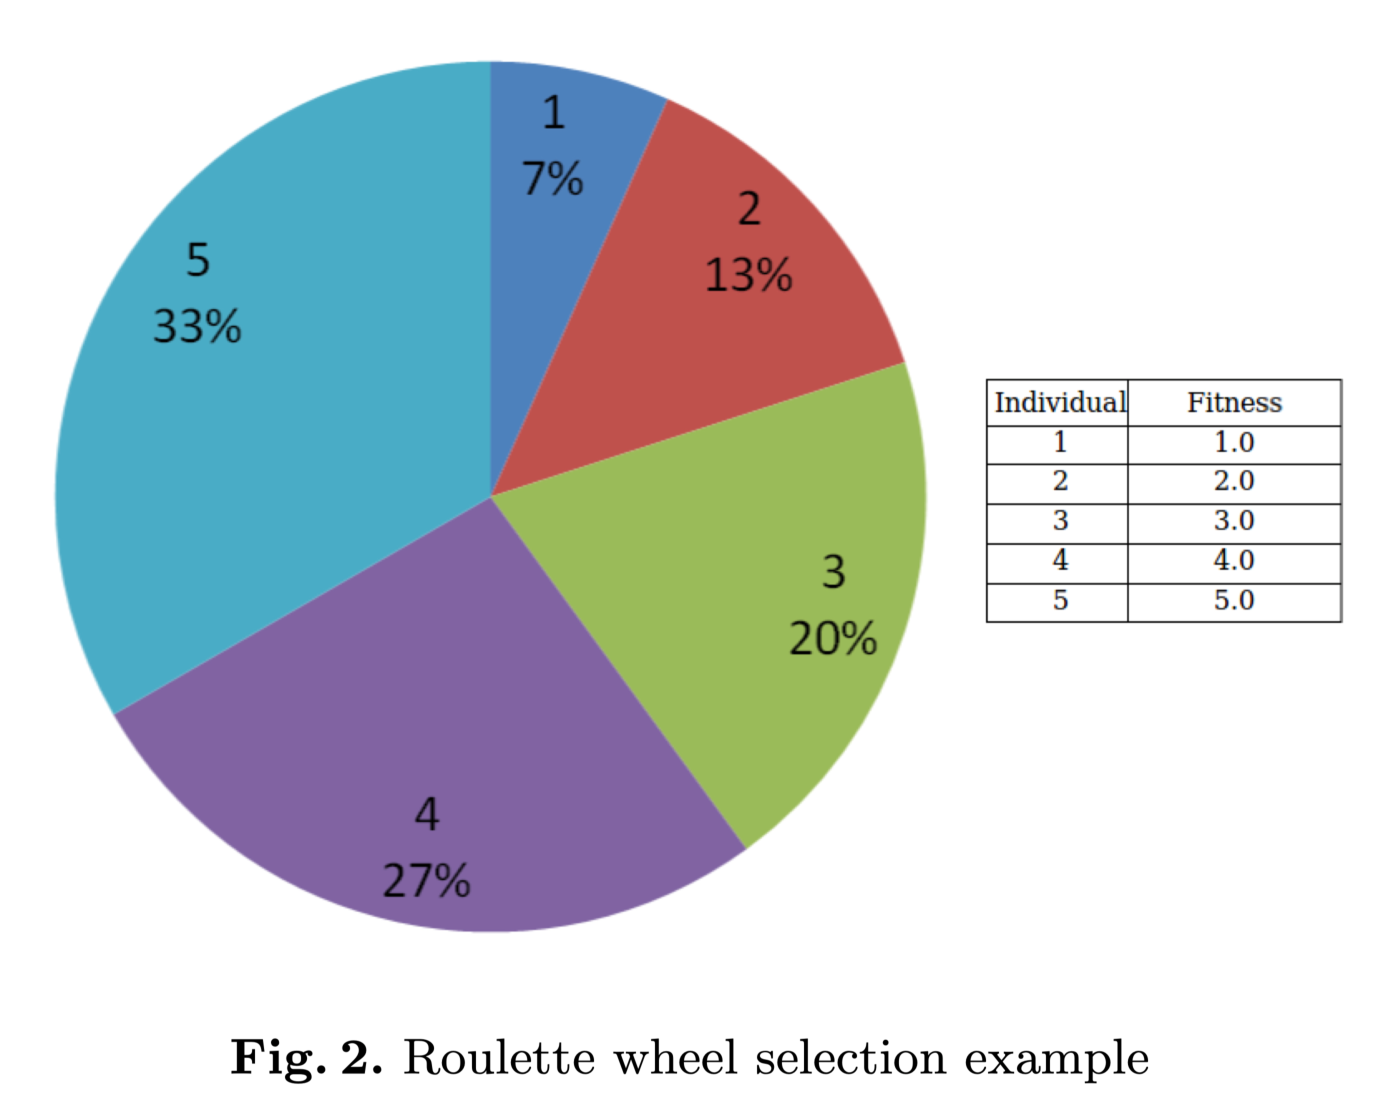

**Attribution** : Santos Amorim et al. (2012)

Quel est l’objectif fondamental de cette méthode de sélection ? Pourquoi
ne pas simplement choisir les individus ayant la meilleure aptitude ?

L’objectif fondamental est de maintenir une population diversifiée.

### **Avantages**

1.  **Proportionnalité de l’aptitude**

    -   **Implémentation simple** : La méthode est simple à mettre en
        œuvre, nécessitant le calcul des probabilités cumulées à partir
        des valeurs d’aptitude.
    -   **Tous les individus ont une chance** : Même les individus ayant
        une aptitude plus faible ont une probabilité non nulle d’être
        sélectionnés, ce qui maintient la diversité génétique.

2.  **Pression de sélection ajustée par l’aptitude**

    -   **Pression dynamique** : La pression de sélection s’ajuste
        naturellement en fonction de la distribution des aptitudes dans
        la population.
    -   **Favorise les individus de haute aptitude** : Les individus
        ayant une aptitude plus élevée sont plus susceptibles d’être
        sélectionnés, favorisant la propagation des traits avantageux.

### **Inconvénients**

1.  **Sensibilité à l’échelle des aptitudes**

    -   **Valeurs d’aptitude négatives** : Si les valeurs d’aptitude
        sont négatives ou nulles (ce qui peut arriver lorsque des
        pénalités sont appliquées), la méthode devient problématique car
        les probabilités ne peuvent être négatives ou nulles.
    -   **Problèmes d’échelle** : Lorsque les valeurs d’aptitude sont
        très proches ou ont une petite amplitude, les probabilités de
        sélection deviennent presque uniformes, réduisant la pression de
        sélection.

2.  **Risque de convergence prématurée**

    -   **Domination des individus de haute aptitude** : Si quelques
        individus ont une aptitude nettement supérieure, ils peuvent
        dominer le processus de sélection, réduisant la diversité et
        conduisant à une convergence prématurée vers des solutions
        sous-optimales.

3.  **Surcharge computationnelle**

    -   **Normalisation requise** : Les valeurs d’aptitude doivent être
        normalisées en probabilités, ce qui ajoute des étapes de calcul,
        surtout si des ajustements sont nécessaires pour des valeurs
        d’aptitude négatives.

## `roulette_selection`

In [9]:
def roulette_selection(population, fitness):

    # Ajuster l'aptitude pour qu'elle ne soit pas négative
    min_fitness = np.min(fitness)
    adjusted_fitness = fitness - min_fitness + 1e-6  # petite valeur epsilon pour éviter la division par zéro

    total_fitness = np.sum(adjusted_fitness)
    probabilities = adjusted_fitness / total_fitness

    pop_size = population.shape[0]
    selected_indices = np.random.choice(pop_size, size=pop_size, p=probabilities)

    return population[selected_indices]

En vos propres termes, que fait `roulette_selection` ?

Une petite valeur est ajoutée aux valeurs d’aptitude ajustées pour
éviter la division par zéro.

Retourne une population de même taille. Les individus les plus aptes
devraient maintenant être plus représentés.

## Croisement

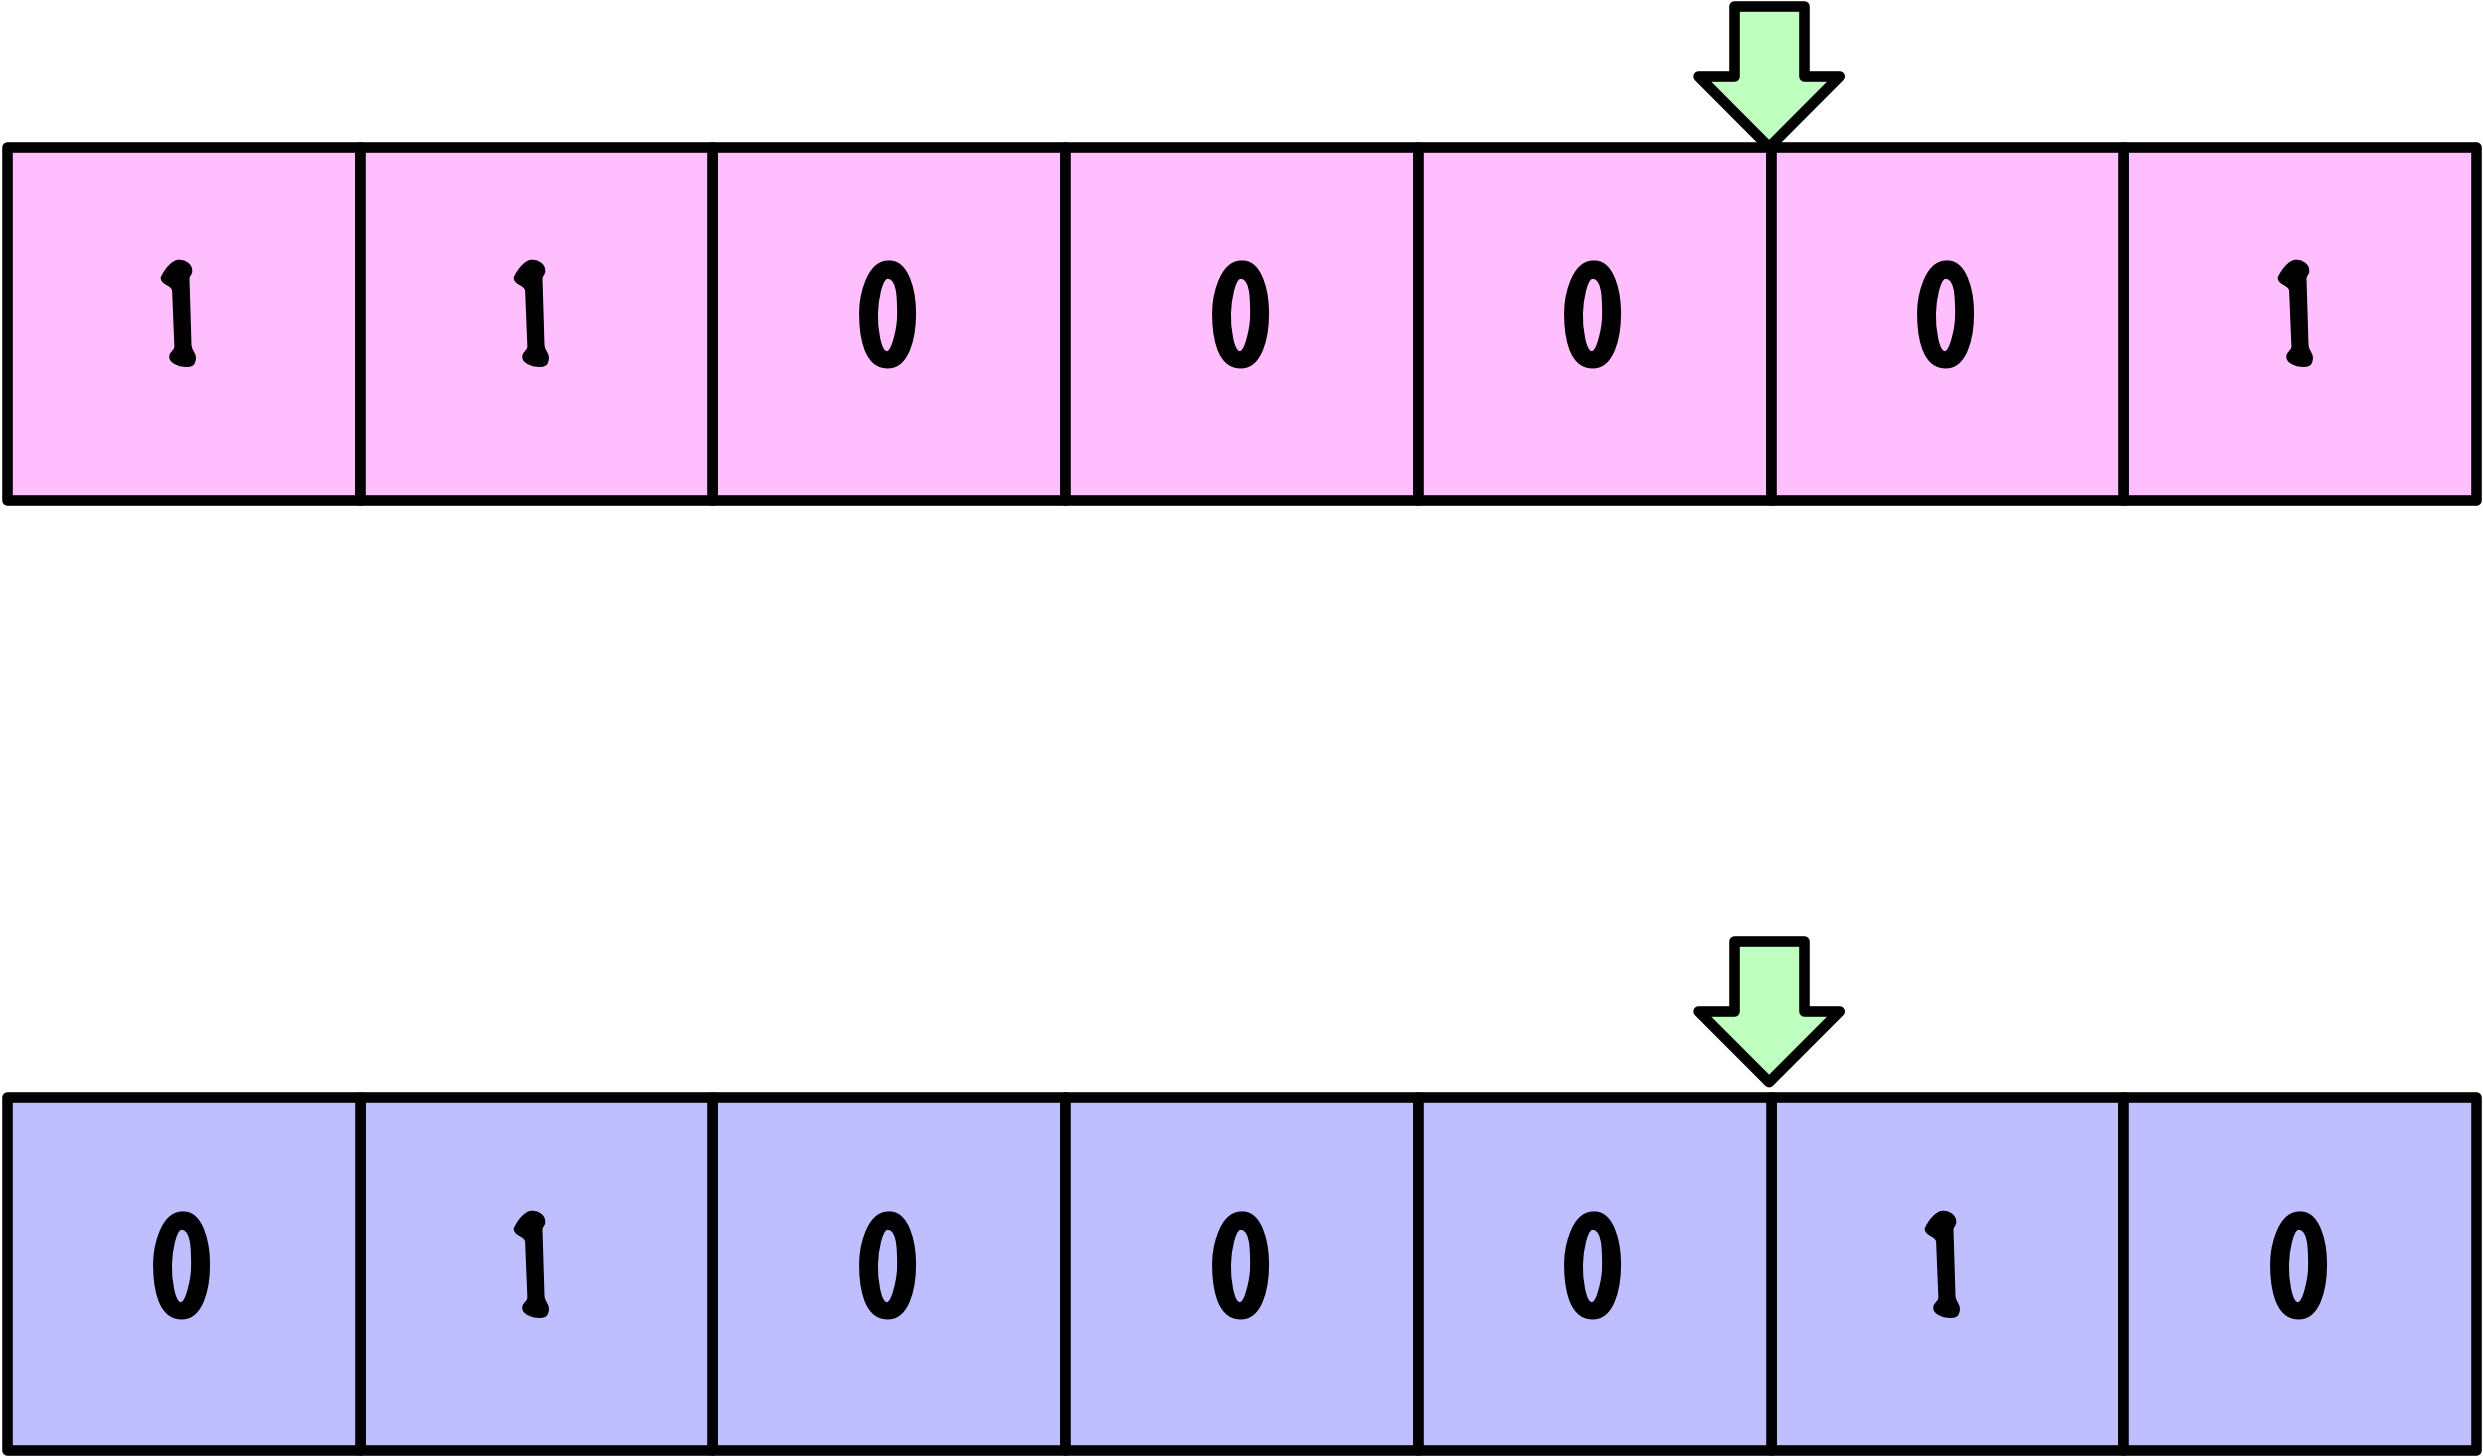

Dans la méthode de **croisement à point unique**, un point de croisement
est **sélectionné aléatoirement**. L’enfant 1 est créé en combinant le
**préfixe** du parent 1 avec le **suffixe** du parent 2, tandis que
l’enfant 2 est formé en joignant le suffixe du parent 1 avec le préfixe
du parent 2.

## Croisement

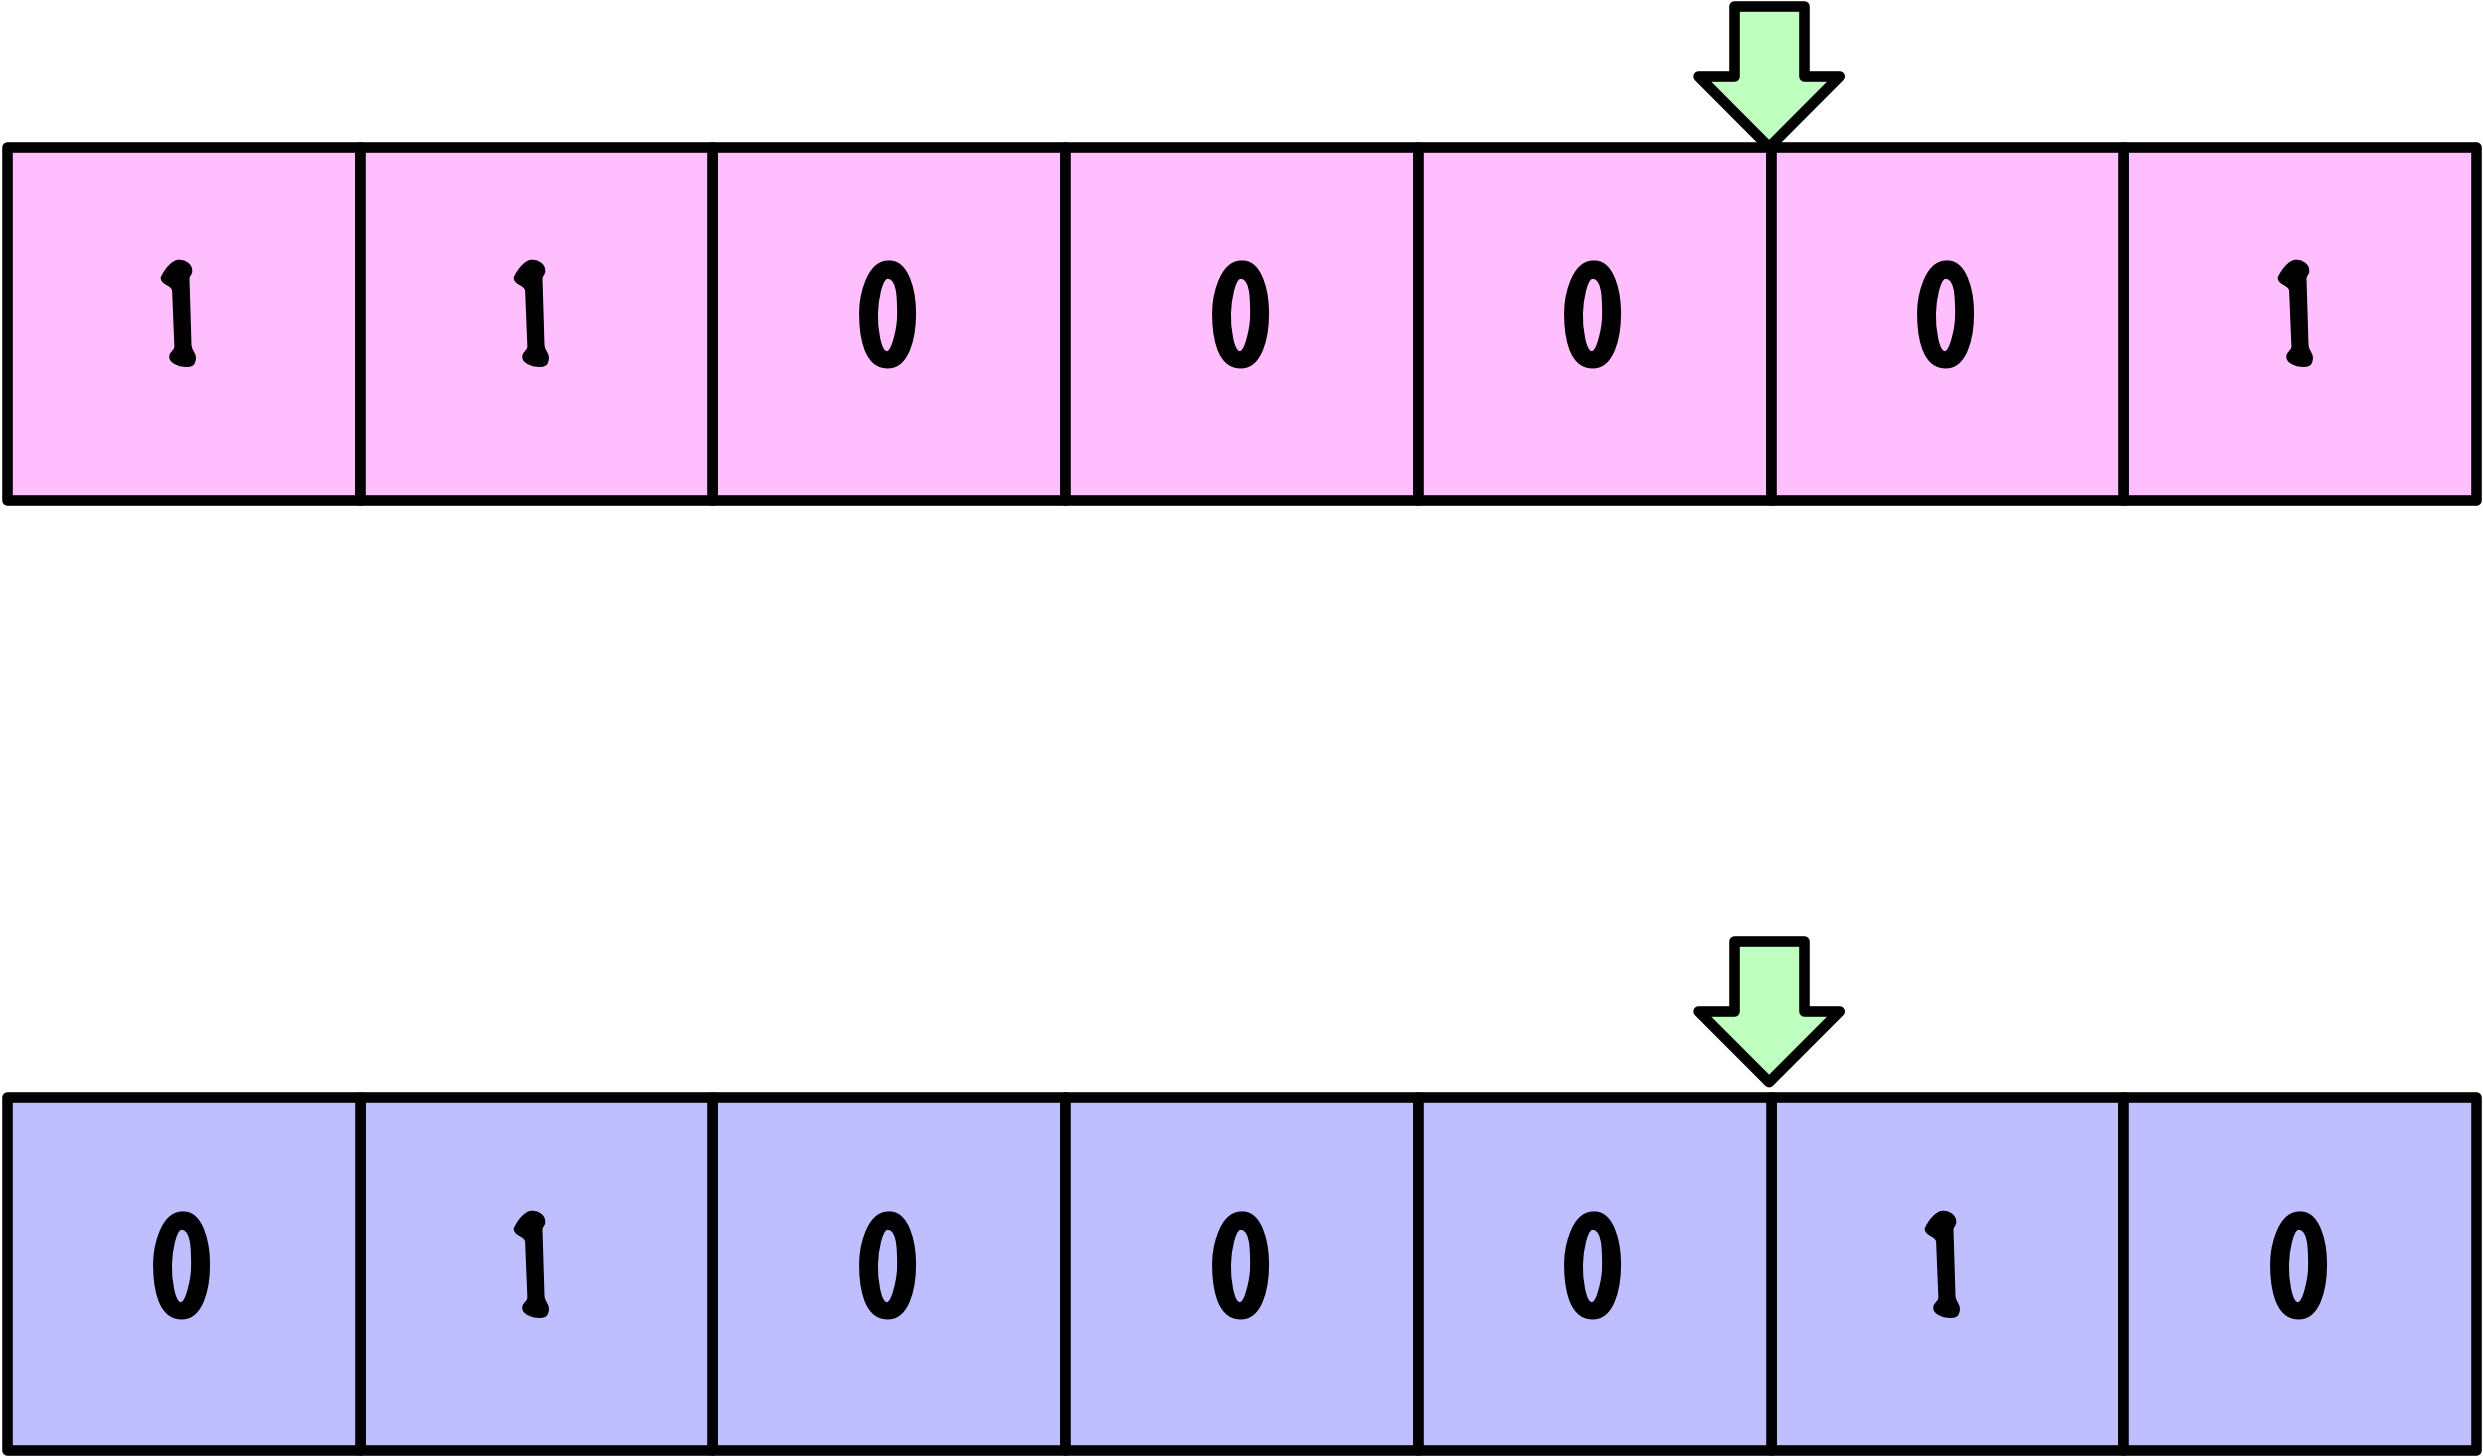

Parents

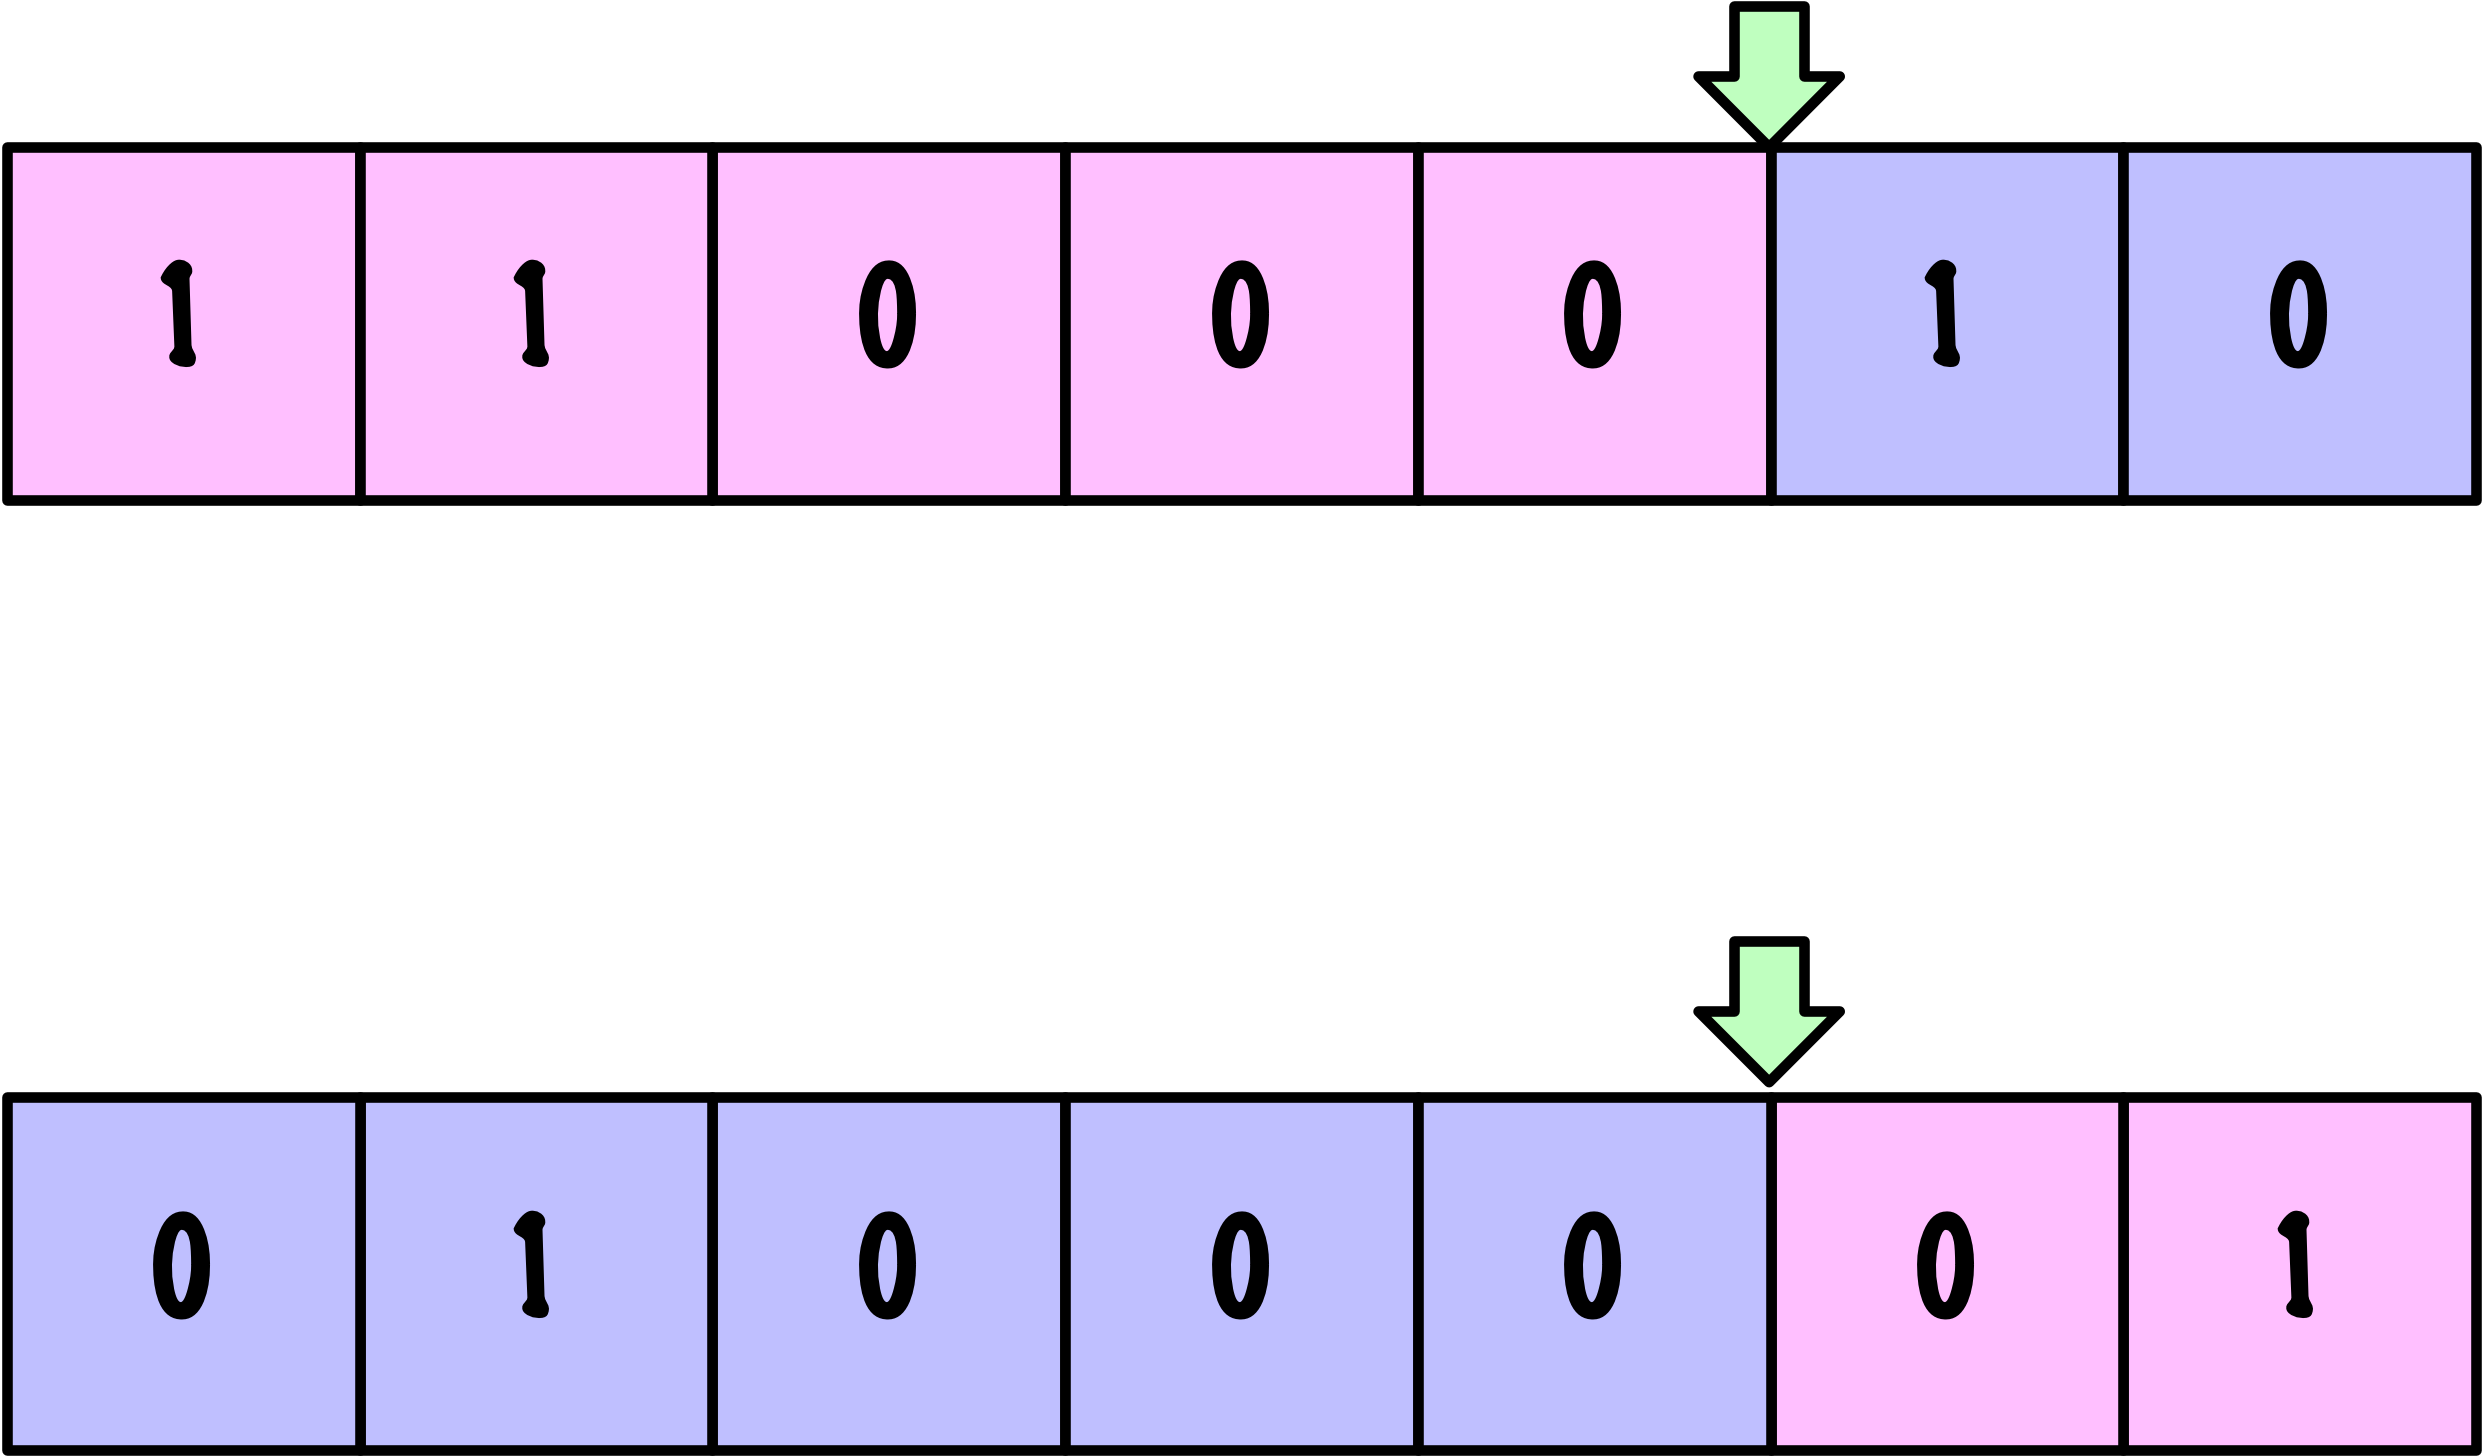

Descendants

Deux **individus parents** produisent deux **descendants**.

## Croisement

In [10]:
def single_point_crossover(parents, crossover_rate):

    num_parents, num_genes = parents.shape
    np.random.shuffle(parents)
    offspring = []

    for i in range(0, num_parents, 2):

        parent1 = parents[i]
        parent2 = parents[i+1 if i+1 < num_parents else 0]

        child1 = parent1.copy()
        child2 = parent2.copy()

        if np.random.rand() < crossover_rate:
            point = np.random.randint(1, num_genes)  # Point de croisement
            child1[:point], child2[:point] = parent2[:point], parent1[:point]

        offspring.append(child1)
        offspring.append(child2)

    return np.array(offspring)

Contrôlé par un paramètre utilisateur, `crossover_rate`, typiquement
fixé à 0,8.

## Mutation

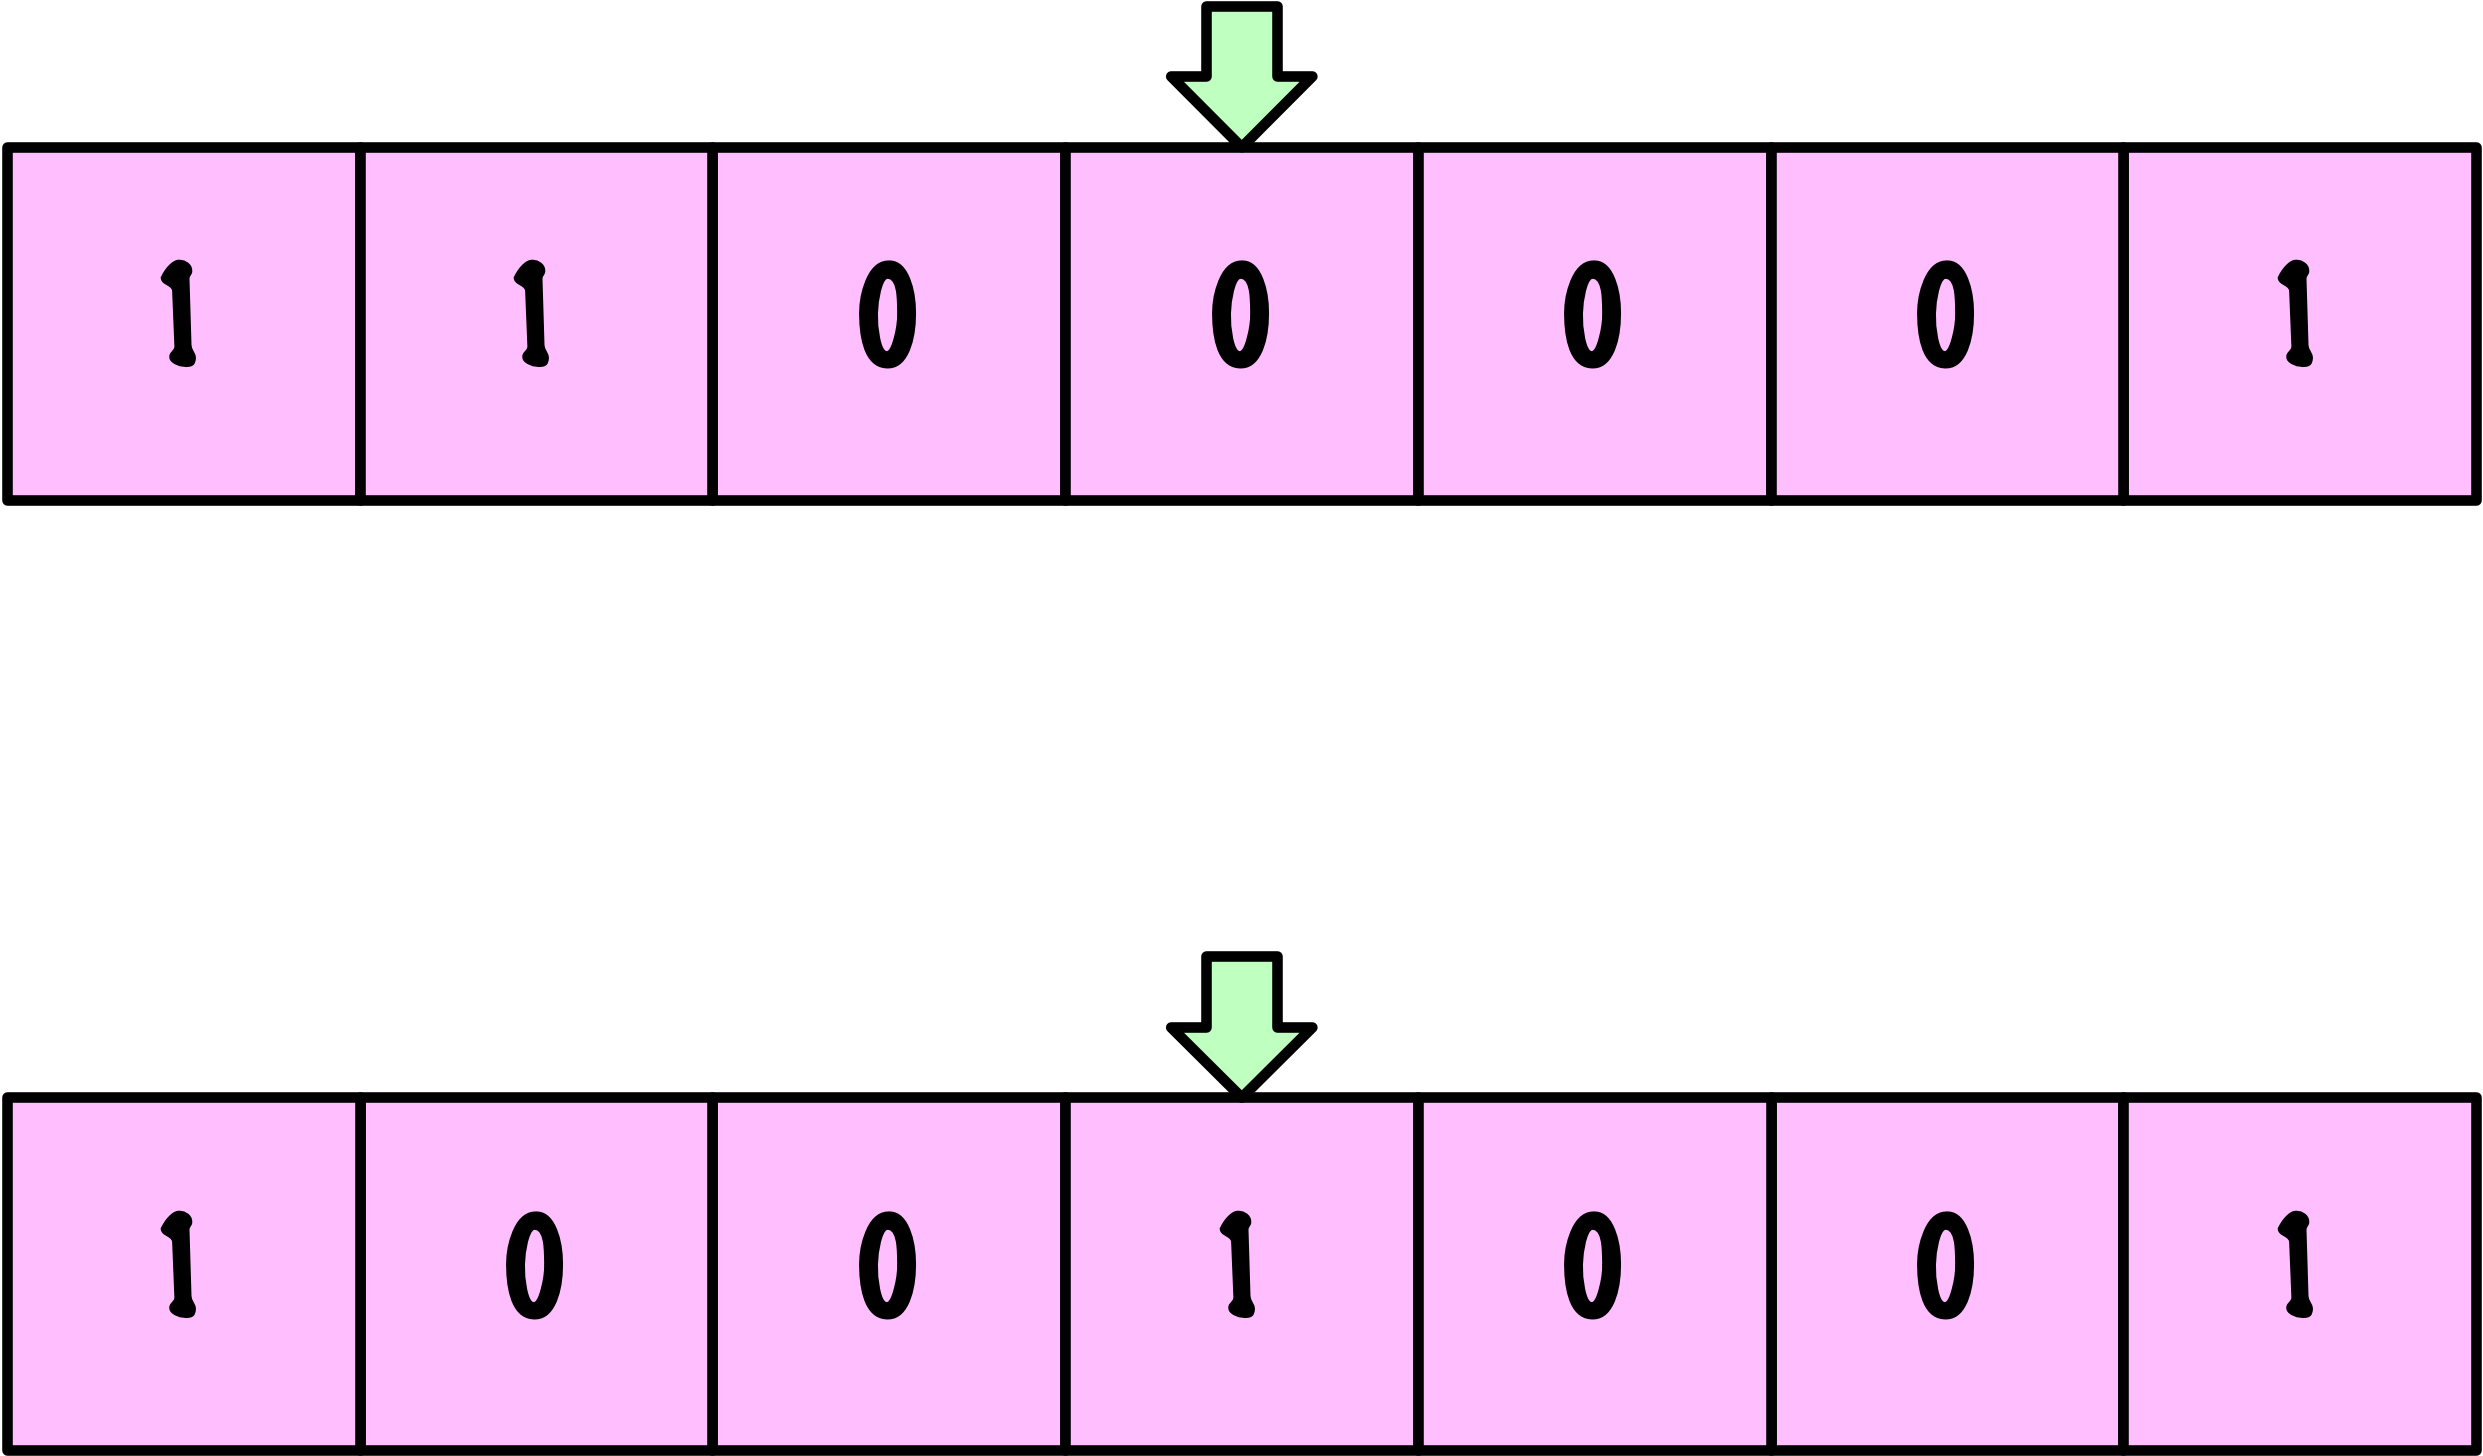

Dans ce scénario de base, une **mutation** consiste à “inverser” un bit.

## Mutation

In [11]:
def mutation(offspring, mutation_rate):

    num_offspring, num_genes = offspring.shape

    mutation_matrix = np.random.rand(num_offspring, num_genes) < mutation_rate

    offspring[mutation_matrix] = 1 - offspring[mutation_matrix]

    return offspring

Un paramètre utilisateur, le **taux de mutation**, détermine si une
**position** subit une mutation.

## Clarification

In [12]:
np.random.seed(42)

offspring = initialize_population(4, 10)

num_offspring, num_genes = offspring.shape

print("Descendants :")
print(offspring)

Descendants :
[[0 1 0 0 0 1 0 0 0 1]
 [0 0 0 0 1 0 1 1 1 0]
 [1 0 1 1 1 1 1 1 1 1]
 [0 0 1 1 1 0 1 0 0 0]]

In [13]:
mutation_rate = 0.05
mutation_matrix = np.random.rand(num_offspring, num_genes) < mutation_rate

print("Matrice de mutation :")
print(mutation_matrix)

Matrice de mutation :
[[False False False False False False False False False  True]
 [False False False False False False False False False False]
 [False False  True False False False False False False False]
 [False False False False False False False False  True False]]

In [14]:
print("offspring[mutation_matrix] :")
print(offspring[mutation_matrix])

offspring[mutation_matrix] :
[1 1 0]

In [15]:
print("1 - offspring[mutation_matrix] :")
print(1 - offspring[mutation_matrix])

1 - offspring[mutation_matrix] :
[0 0 1]

In [16]:
offspring[mutation_matrix] = 1 - offspring[mutation_matrix]

print("Descendants mutés :")
print(offspring)

Descendants mutés :
[[0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 1 1 1 0]
 [1 0 0 1 1 1 1 1 1 1]
 [0 0 1 1 1 0 1 0 1 0]]

Cette implémentation utilise largement `Numpy`.

## Élitisme

**L’élitisme** dans les algorithmes génétiques est une stratégie où un
sous-ensemble des individus les plus aptes de la génération actuelle est
directement transféré à la génération suivante.

Cette approche garantit que les meilleures solutions sont préservées
tout au long du processus évolutif, accélérant la convergence et
maintenant des solutions de haute qualité au sein de la population.

## Élitisme

In [17]:
def elitism(population, fitness, elite_size):

    elite_indices = np.argsort(fitness)[-elite_size:]  # Obtenir les indices des meilleurs individus

    elites = population[elite_indices]

    return elites

## Algorithme Génétique (Version 1)

In [18]:
def genetic_algorithm(weights, values, capacity, pop_size=100, 
                      num_generations=100, crossover_rate=0.8,
                      mutation_rate=0.05, elite_percent=0.02):

    num_items = len(weights)
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_items)

    for generation in range(num_generations):

        fitness = evaluate_fitness(population, weights, values, capacity)

        # Élitisme
        elites = elitism(population, fitness, elite_size)

        # Sélection
        parents = roulette_selection(population, fitness)

        # Croisement
        offspring = single_point_crossover(parents, crossover_rate)

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Création d'une nouvelle population
        population = np.vstack((elites, offspring))

        # Assurer la taille de la population
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            # Ajouter des individus aléatoires pour combler la population
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_items)
            population = np.vstack((population, new_individuals))

    # Après toutes les générations, retourner la meilleure solution
    fitness = evaluate_fitness(population, weights, values, capacity)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_value = np.dot(best_solution, values)
    best_weight = np.dot(best_solution, weights)

    return best_solution, best_value, best_weight

## Exécution

In [19]:
np.random.seed(13)

solution, total_value, total_weight = genetic_algorithm(weights, values, capacity)

print(f"Solution: {solution}")
print(f"Valeur: {total_value}")
print(f"Poids: {total_weight}")

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 1]
Valeur: 7357
Poids: 848

## Algorithme Génétique (Version 1.1)

In [20]:
def genetic_algorithm(weights, values, capacity, pop_size=100, 
                      num_generations=100, crossover_rate=0.8, 
                      mutation_rate=0.05, elite_percent=0.02):

    num_items = len(weights)
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_items)

    average_fitness_history = []
    best_fitness_history = []

    for generation in range(num_generations):

        fitness = evaluate_fitness(population, weights, values, capacity)

        # Suivi de l'aptitude moyenne et de la meilleure aptitude
        average_fitness = np.mean(fitness)
        best_fitness = np.max(fitness)
        average_fitness_history.append(average_fitness)
        best_fitness_history.append(best_fitness)

        # Élitisme
        elites = elitism(population, fitness, elite_size)

        # Sélection
        parents = roulette_selection(population, fitness)

        # Croisement
        offspring = single_point_crossover(parents, crossover_rate)

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Création d'une nouvelle population
        population = np.vstack((elites, offspring))

        # Assurer la taille de la population
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            # Ajouter des individus aléatoires pour combler la population
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_items)
            population = np.vstack((population, new_individuals))

    # Après toutes les générations, retourner la meilleure solution
    fitness = evaluate_fitness(population, weights, values, capacity)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_value = np.dot(best_solution, values)
    best_weight = np.dot(best_solution, weights)

    return best_solution, best_value, best_weight, average_fitness_history, best_fitness_history

## Visualisation

In [21]:
import matplotlib.pyplot as plt

def plot_fitness_over_generations(avg_fitness_history, best_fitness_history):

    generations = range(1, len(avg_fitness_history) + 1)

    plt.figure(figsize=(6, 6))

    plt.plot(generations, avg_fitness_history, label='Aptitude Moyenne')
    plt.plot(generations, best_fitness_history, label='Meilleure Aptitude')
    plt.xlabel('Génération')
    plt.ylabel('Aptitude')
    plt.title('Aptitude au fil des Générations')
    plt.legend()

## Exécution

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 1]
Valeur: 7357
Poids: 848

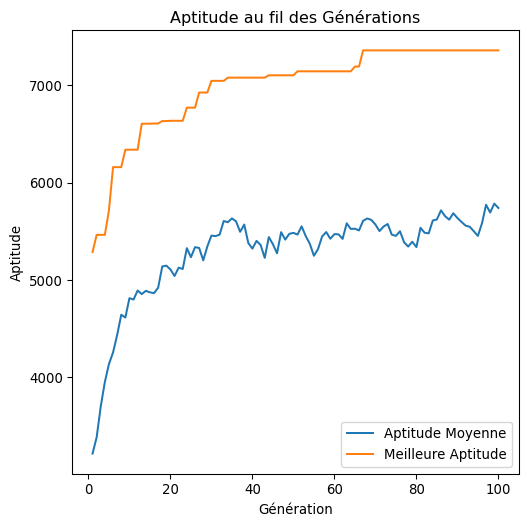

In [22]:
np.random.seed(13)

solution, total_value, total_weight, avg_fitness_history, best_fitness_history = genetic_algorithm(weights, values, capacity)

print(f"Solution: {solution}")
print(f"Valeur: {total_value}")
print(f"Poids: {total_weight}")

plot_fitness_over_generations(avg_fitness_history, best_fitness_history)

## Exécution (Version 2)

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 0 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Valeur: 7506
Poids: 846

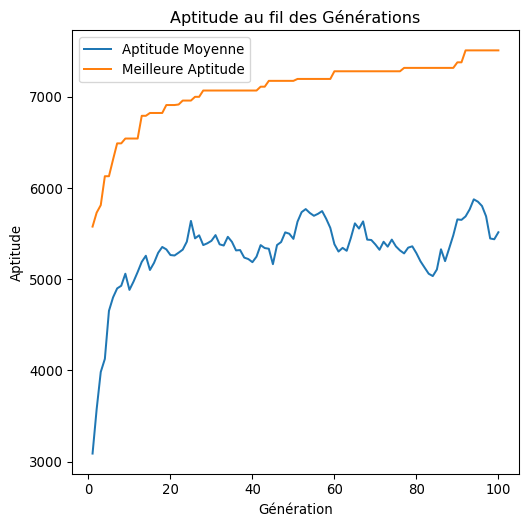

In [23]:
np.random.seed(42)

best_value = -1
best_weight = -1
best_solution, best_averages, best_bests = None, None, None

for i in range(100):

    solution, total_value, total_weight, avg_fitness_history, best_fitness_history = genetic_algorithm(
        weights, values, capacity
    )

    if total_value > best_value and total_weight <= capacity:
        best_value = total_value
        best_weight = total_weight
        best_solution = solution
        best_averages = avg_fitness_history
        best_bests = best_fitness_history

print(f"Solution: {best_solution}")
print(f"Valeur: {best_value}")
print(f"Poids: {best_weight}")

plot_fitness_over_generations(best_averages, best_bests)

## Utilisation de Google OR-Tools

In [24]:
# https://developers.google.com/optimization/pack/knapsack

from ortools.algorithms.python import knapsack_solver

def solve_using_ortools(values, weights, capacity):

    weights = [weights]

    # Création du solveur
    solver = knapsack_solver.KnapsackSolver(
        knapsack_solver.SolverType.KNAPSACK_MULTIDIMENSION_BRANCH_AND_BOUND_SOLVER,
        "KnapsackExample",
    )

    solver.init(values, weights, [capacity])

    computed_value = solver.solve()

    packed_items = []
    packed_weights = []
    total_weight = 0
    print("Valeur totale =", computed_value)
    for i in range(len(values)):
        if solver.best_solution_contains(i):
            packed_items.append(i)
            packed_weights.append(weights[0][i])
            total_weight += weights[0][i]
    print("Poids total :", total_weight)
    print("Objets sélectionnés :", packed_items)
    print("Poids des objets sélectionnés :", packed_weights)

## Résolution avec OR-Tools

In [25]:
solve_using_ortools(values, weights, capacity)

Valeur totale = 7534
Poids total : 850
Objets sélectionnés : [0, 1, 3, 4, 6, 10, 11, 12, 14, 15, 16, 17, 18, 19, 21, 22, 24, 27, 28, 29, 30, 31, 32, 34, 38, 39, 41, 42, 44, 47, 48, 49]
Poids des objets sélectionnés : [7, 0, 22, 80, 11, 59, 18, 0, 3, 8, 15, 42, 9, 0, 47, 52, 26, 6, 29, 84, 2, 4, 18, 7, 71, 3, 66, 31, 0, 65, 52, 13]

# Discussion

## Schémas de codage

-   **Encodage binaire** : Souvent utilisé.
-   **Encodage par permutation** : Utilisé typiquement pour des
    problèmes comme le **voyageur de commerce** ou le problème des
    N-Reines.
-   **Codage par valeurs** : Ce codage utilise des valeurs entières,
    réelles ou des caractères. Exemple : apprendre les paramètres d’un
    polynôme pour un problème de régression.

## Sélection par tournoi

La **sélection par tournoi** consiste à sélectionner aléatoirement un
sous-ensemble d’individus (un tournoi) dans la population, puis à
choisir le meilleur individu de ce sous-ensemble comme parent. Ce
processus est répété jusqu’à ce que le nombre requis de parents soit
sélectionné.

Cette méthode équilibre **exploration** et **exploitation**, permettant
de contrôler la pression de sélection en modifiant la taille du tournoi.
**Des tournois plus grands augmentent la pression de sélection**,
favorisant davantage les individus les plus aptes.

### **Avantages**

1.  **Robustesse face aux échelles d’aptitude**
    -   **Gestion des valeurs d’aptitude négatives** : La méthode repose
        sur le classement relatif au sein du tournoi, et non sur les
        valeurs absolues d’aptitude, ce qui la rend robuste face aux
        aptitudes négatives ou nulles.
    -   **Insensibilité à la distribution des aptitudes** : Étant basé
        sur la comparaison plutôt que sur la proportion, il fonctionne
        bien même lorsque les valeurs d’aptitude sont proches.
2.  **Pression de sélection ajustable**
    -   **Contrôle via la taille du tournoi** :
        -   **Grands tournois** : Pression de sélection élevée,
            favorisant fortement les individus les plus aptes.
        -   **Petits tournois** : Pression de sélection faible,
            favorisant la diversité.
    -   **Simplicité** : Facile à implémenter sans nécessiter de
        normalisation des aptitudes.
3.  **Maintien de la diversité**
    -   **Évite la convergence prématurée** : En ne se concentrant pas
        uniquement sur les individus les plus aptes, il maintient la
        diversité génétique dans la population.

### **Inconvénients**

1.  **Nature stochastique**
    -   **Aléatoire dans la sélection** : Le processus est plus
        aléatoire, et le meilleur individu de la population pourrait ne
        pas être sélectionné s’il n’est pas inclus dans un tournoi.
    -   **Convergence lente possible** : Si la taille du tournoi est
        trop petite, l’algorithme peut converger lentement en raison
        d’une faible pression de sélection.
2.  **Dépendance aux paramètres**
    -   **Nécessite un réglage** : Les performances dépendent de la
        taille du tournoi, qui peut nécessiter des essais pour
        optimisation.
3.  **Considérations computationnelles**
    -   **Multiples comparaisons** : Nécessite des échantillonnages
        aléatoires et des comparaisons, ce qui peut être plus intensif
        en calcul pour des populations très larges, bien que cela reste
        généralement négligeable.

## `tournament_selection`

In [26]:
def tournament_selection(population, fitness, tournament_size):

    pop_size = population.shape[0]

    selected_indices = []

    for _ in range(pop_size):

        participants = np.random.choice(pop_size, tournament_size, replace=False)

        best = participants[np.argmax(fitness[participants])]

        selected_indices.append(best)

    return population[selected_indices]

Les valeurs typiques pour `tournament_size` sont 2, 3, 4 ou 5.

## Discussion

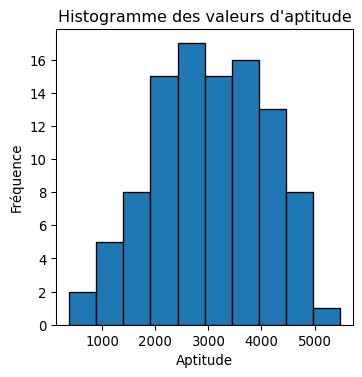

tournament_size: 2, fitness: 1985
tournament_size: 4, fitness: 2933
tournament_size: 8, fitness: 3966
tournament_size: 100, fitness: 5478

In [27]:
np.random.seed(27)

pop_size, num_items = 100, 50

population = initialize_population(pop_size, num_items)

fitness = evaluate_fitness(population, weights, values, capacity)

plt.figure(figsize=(4, 4))
plt.hist(fitness, bins=10, edgecolor='black')
plt.xlabel('Aptitude')
plt.ylabel('Fréquence')
plt.title("Histogramme des valeurs d'aptitude")
plt.show()

for tournament_size in [2, 4, 8, pop_size]:
  participants = np.random.choice(pop_size, tournament_size, replace=False)
  print(f"tournament_size: {tournament_size}, fitness: {max(fitness[participants])}")

-   Plus petit $k$ (par exemple, $k = 2$) : Une faible pression de
    sélection favorise la diversité et l’exploration, utile dans les
    premières générations.

-   Plus grand $k$ (par exemple, $k = 5$) : Une forte pression de
    sélection accélère la convergence, en mettant l’accent sur
    l’exploitation, idéale dans les générations ultérieures.

## Algorithme Génétique (Version 2)

In [28]:
def genetic_algorithm(weights, values, capacity, pop_size=100, 
                      num_generations=100, crossover_rate=0.8,
                      mutation_rate=0.05, elite_percent=0.02, 
                      selection_type='tournament', tournament_size=3):

    num_items = len(weights)
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_items)

    average_fitness_history = []
    best_fitness_history = []

    for generation in range(num_generations):

        fitness = evaluate_fitness(population, weights, values, capacity)

        # Suivi de l'aptitude moyenne et de la meilleure aptitude
        average_fitness = np.mean(fitness)
        best_fitness = np.max(fitness)
        average_fitness_history.append(average_fitness)
        best_fitness_history.append(best_fitness)

        # Élitisme
        elites = elitism(population, fitness, elite_size)

        # Sélection
        if selection_type == 'tournament':
            parents = tournament_selection(population, fitness, tournament_size)
        elif selection_type == 'roulette':
            parents = roulette_selection(population, fitness)
        else:
            raise ValueError("Type de sélection invalide")

        # Croisement
        offspring = single_point_crossover(parents, crossover_rate)

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Création d'une nouvelle population
        population = np.vstack((elites, offspring))

        # Assurer la taille de la population
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            # Ajouter des individus aléatoires pour combler la population
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_items)
            population = np.vstack((population, new_individuals))

    # Après toutes les générations, retourner la meilleure solution
    fitness = evaluate_fitness(population, weights, values, capacity)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_value = np.dot(best_solution, values)
    best_weight = np.dot(best_solution, weights)

    return best_solution, best_value, best_weight, average_fitness_history, best_fitness_history

## Exécution

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Valeur: 7534
Poids: 850

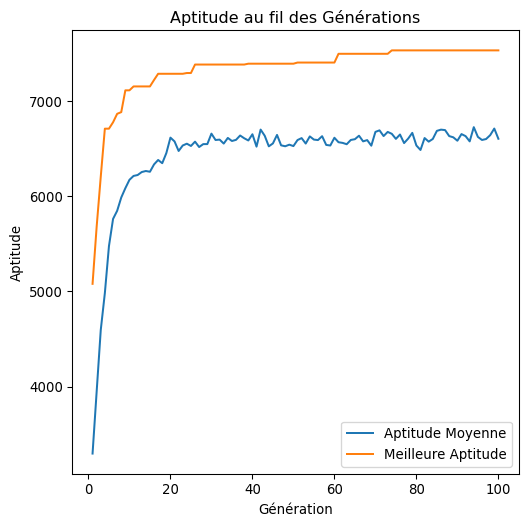

In [29]:
np.random.seed(42)

best_value, best_weight = -1, -1
best_solution, best_averages, best_bests = None, None, None

for i in range(100):

    solution, total_value, total_weight, avg_fitness_history, best_fitness_history = genetic_algorithm(
        weights, values, capacity, tournament_size=4
    )

    if total_value > best_value and total_weight <= capacity:
        best_value = total_value
        best_weight = total_weight
        best_solution = solution
        best_averages = avg_fitness_history
        best_bests = best_fitness_history

print(f"Solution: {best_solution}")
print(f"Valeur: {best_value}")
print(f"Poids: {best_weight}")

plot_fitness_over_generations(best_averages, best_bests)

## `tournament_size=2, 4, 8`

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Value: 7534
Weight: 850
Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Value: 7534
Weight: 850
Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Value: 7534
Weight: 850

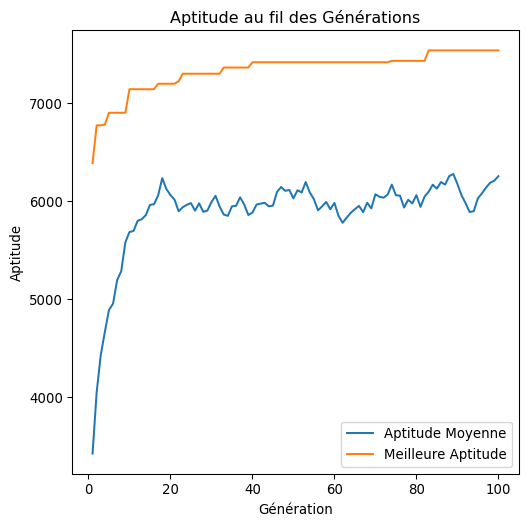

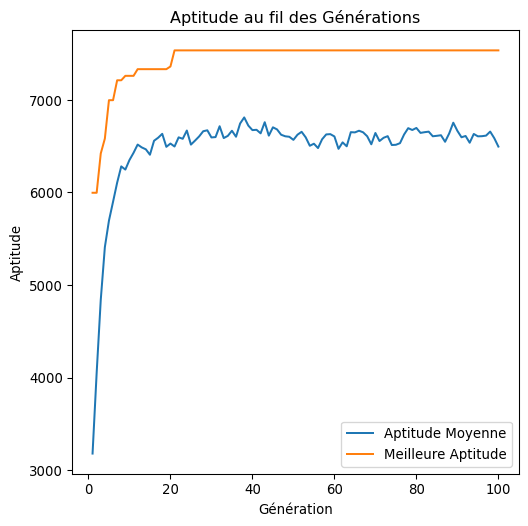

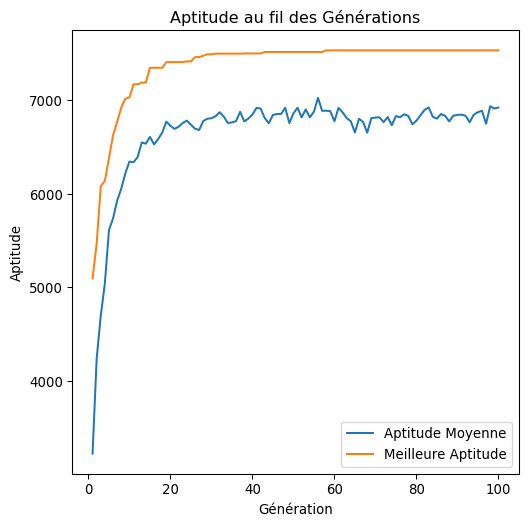

In [30]:
np.random.seed(42)

for tournament_size in (2, 4, 8):

  best_value = -1
  best_weight = -1
  best_solution, best_averages, best_bests = None,  None, None

  for i in range(100):

      solution, total_value, total_weight, avg_fitness_history, best_fitness_history = genetic_algorithm(
        weights, values, capacity, tournament_size=tournament_size
      )

      if total_value > best_value and total_weight <= capacity:
        best_value = total_value
        best_weight = total_weight
        best_solution = solution
        best_averages = avg_fitness_history
        best_bests = best_fitness_history

  print(f"Solution: {best_solution}")
  print(f"Value: {best_value}")
  print(f"Weight: {best_weight}")

  plot_fitness_over_generations(best_averages, best_bests)

À mesure que l’on augmente la taille du tournoi, la moyenne et le
meilleur fitness se rapprochent. Convergence plus rapide.

## Croisement

-   **Croisement à un point** ou **à k points**.

Le croisement à k points est une technique d’algorithme génétique
utilisée pour combiner deux solutions parentales afin de générer une
descendance. Il consiste à sélectionner $k$ points de croisement et à
échanger des segments des parents entre ces points. Voici quelques
scénarios où le croisement à k points peut être particulièrement utile :

1.  **Espaces de solutions complexes** : Lorsque le domaine du problème
    implique des interdépendances complexes entre les variables, le
    croisement à k points peut aider à explorer plus en profondeur
    l’espace de solutions en permettant l’échange de plusieurs segments
    entre les parents.

2.  **Matériel génétique diversifié** : En augmentant $k$, plus de
    matériel génétique des deux parents est mélangé, ce qui peut
    introduire une plus grande diversité dans la descendance. Cela peut
    être bénéfique pour éviter une convergence prématurée vers des
    solutions sous-optimales.

3.  **Équilibre entre exploration et exploitation** : Le croisement à k
    points offre un équilibre entre l’exploration (en introduisant de
    nouvelles combinaisons de matériel génétique) et l’exploitation (en
    maintenant une certaine continuité avec les solutions parentales).
    Cela peut être avantageux pour maintenir une diversité saine dans la
    population.

4.  **Ajustement des performances de l’algorithme génétique** : Ajuster
    le nombre de points de croisement ($k$) permet de peaufiner les
    performances de l’algorithme génétique. Un $k$ plus élevé peut être
    utilisé pour augmenter la diversité, tandis qu’un $k$ plus bas peut
    se concentrer sur l’exploitation des bonnes solutions connues.

5.  **Représentations de solutions larges** : Dans les problèmes avec de
    grandes représentations de solutions, comme de longues chaînes
    binaires ou de grands tableaux, le croisement à k points permet un
    mélange plus nuancé du matériel génétique, ce qui peut mener à une
    recherche et une optimisation plus efficaces.

6.  **Tests empiriques** : Parfois, le croisement à k points est choisi
    sur la base de résultats empiriques, où l’expérimentation montre
    qu’il fonctionne mieux pour un problème ou un ensemble de données
    spécifique par rapport à d’autres méthodes de croisement.

Le croisement à k points est polyvalent et peut être adapté aux besoins
de différents problèmes en ajustant le nombre de points de croisement,
ce qui en fait un outil utile dans la boîte à outils des algorithmes
génétiques.

## Croisement uniforme

Le **croisement uniforme** dans les algorithmes génétiques est une
technique de recombinaison où **chaque gène** de la descendance est
**choisi indépendamment** de l’un des deux génomes parentaux avec une
probabilité égale. Cette approche permet une **combinaison plus variée
des traits parentaux** par rapport aux méthodes de croisement
traditionnelles, favorisant **une plus grande diversité génétique** dans
la population résultante.

## `uniform_crossover`

In [31]:
def uniform_crossover(parents, crossover_rate):

    num_parents, num_genes = parents.shape
    np.random.shuffle(parents)

    offspring = []

    for i in range(0, num_parents, 2):

        parent1 = parents[i]
        parent2 = parents[i+1 if i+1 < num_parents else 0]

        child1 = parent1.copy()
        child2 = parent2.copy()

        if np.random.rand() < crossover_rate:

            mask = np.random.randint(0, 2, size=num_genes).astype(bool)

            child1[mask], child2[mask] = parent2[mask], parent1[mask]

        offspring.append(child1)
        offspring.append(child2)

    return np.array(offspring)

## Algorithme génétique (Version 3)

In [32]:
def genetic_algorithm(weights, values, capacity, pop_size=100, 
                      num_generations=200, crossover_rate=0.8,
                      mutation_rate=0.05, elite_percent=0.02, 
                      selection_type='tournament', tournament_size=3,
                      crossover_type='single_point'):

    num_items = len(weights)
    elite_size = max(1, int(pop_size * elite_percent))
    population = initialize_population(pop_size, num_items)

    average_fitness_history = []
    best_fitness_history = []

    for generation in range(num_generations):

        fitness = evaluate_fitness(population, weights, values, capacity)

        # Track average and best fitness
        average_fitness = np.mean(fitness)
        best_fitness = np.max(fitness)
        average_fitness_history.append(average_fitness)
        best_fitness_history.append(best_fitness)

        # Elitism
        elites = elitism(population, fitness, elite_size)

        # Selection
        if selection_type == 'tournament':
            parents = tournament_selection(population, fitness, tournament_size)
        elif selection_type == 'roulette':
            parents = roulette_selection(population, fitness)
        else:
            raise ValueError("Invalid selection type")

        # Crossover
        if crossover_type == 'single_point':
            offspring = single_point_crossover(parents, crossover_rate)
        elif crossover_type == 'uniform':
            offspring = uniform_crossover(parents, crossover_rate)
        else:
            raise ValueError("Invalid crossover type")

        # Mutation
        offspring = mutation(offspring, mutation_rate)

        # Create new population
        population = np.vstack((elites, offspring))

        # Ensure population size
        if population.shape[0] > pop_size:
            population = population[:pop_size]
        elif population.shape[0] < pop_size:
            # Add random individuals to fill population
            num_new_individuals = pop_size - population.shape[0]
            new_individuals = initialize_population(num_new_individuals, num_items)
            population = np.vstack((population, new_individuals))

    # After all generations, return the best solution
    fitness = evaluate_fitness(population, weights, values, capacity)
    best_index = np.argmax(fitness)
    best_solution = population[best_index]
    best_value = np.dot(best_solution, values)
    best_weight = np.dot(best_solution, weights)

    return best_solution, best_value, best_weight, average_fitness_history, best_fitness_history

## Exécution

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Value: 7534
Weight: 850

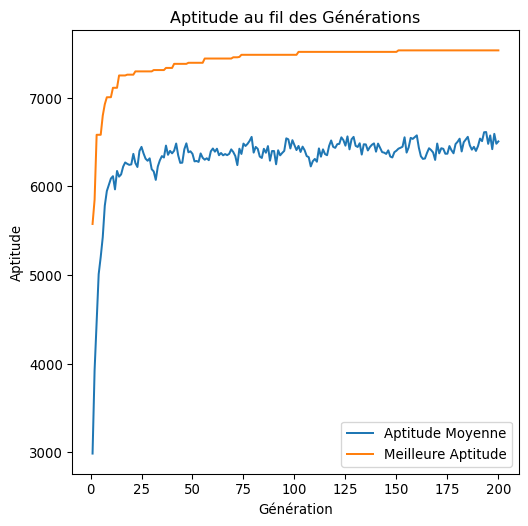

In [33]:
np.random.seed(42)

best_value, best_weight = -1, -1
best_solution, best_averages, best_bests = None,  None, None

for i in range(100):

  solution, total_value, total_weight, avg_fitness_history, best_fitness_history = genetic_algorithm(
    weights, values, capacity, crossover_type='uniform'
  )

  if total_value > best_value and total_weight <= capacity:
    best_value = total_value
    best_weight = total_weight
    best_solution = solution
    best_averages = avg_fitness_history
    best_bests = best_fitness_history


print(f"Solution: {best_solution}")
print(f"Value: {best_value}")
print(f"Weight: {best_weight}")

plot_fitness_over_generations(best_averages, best_bests)

## Comparaison entre croisements

**Le croisement à un point** est avantageux lorsque les **blocs de
construction** (séquences de gènes contiguës) sont **significatifs** et
**bénéfiques à préserver**. Cependant, dans le problème du sac à dos
0/1, la position des objets dans le chromosome est généralement
arbitraire, et préserver des sections contiguës peut ne pas correspondre
à de meilleures solutions.

**Le croisement uniforme** offre une **meilleure exploration** en
mélangeant les gènes de manière indépendante, ce qui s’aligne bien avec
la nature du problème du sac à dos où l’inclusion de chaque objet est
une décision indépendante. Cela réduit le biais de position et augmente
la probabilité de découvrir des combinaisons optimales d’objets.

## Croisement

**Préservation de l’ordre.** Pour chaque descendant, conserver la
séquence des éléments d’un parent tout en remplissant les positions
restantes avec des éléments de l’autre parent, en préservant leur ordre
tel qu’ils apparaissent chez le second parent.

Voir (Cattolico et Cicirello 2006) pour des variantes.

## Croisement d’ordre 1 (OX)

![](https://media.springernature.com/full/springer-static/image/chp%3A10.1007%2F978-981-15-6067-5_60/MediaObjects/486739_1_En_60_Fig2_HTML.png)

**Attribution**: (Bye et al. 2021)

OX est conçu pour préserver l’ordre relatif des éléments d’un parent
tout en comblant les lacunes avec des éléments de l’autre parent.

## Croisement PMX

![](https://media.springernature.com/full/springer-static/image/chp%3A10.1007%2F978-981-15-6067-5_60/MediaObjects/486739_1_En_60_Fig1_HTML.png)

**Attribution**: (Bye et al. 2021) - Croisement partiellement mappé
(PMX)

Le PMX assure la cohérence positionnelle en maintenant l’ordre relatif
des éléments entre les chromosomes parents.

## Comparaison

| Caractéristique | **PMX** | **OX** |
|-------------------------|------------------------|-----------------------|
| **Préservation de la Position** | Élevée | Faible |
| **Préservation de l’Ordre** | Partielle | Élevée |
| **Exploration vs. Exploitation** | Axée sur l’exploitation | Axée sur l’exploration |
| **Complexité de l’Implémentation** | Plus élevée | Plus faible |
| **Adéquation de l’Application** | Problèmes avec des dépendances positionnelles | Problèmes avec des dépendances d’ordre |

## Mutation

-   Dans un **flip de bit**, une position spécifique du chromosome est
    inversée (0 devient 1 et vice versa). C’est la méthode la plus
    courante pour des représentations binaires.

    -   Un **taux de mutation** typique est de $1/n$, où $n$ représente
        la longueur du chromosome. Ce paramètre équilibre l’exploration
        et l’exploitation.

## Mutation

-   **Remplacement ou réinitialisation aléatoire**: Pour des chromosomes
    à valeurs entières ou réelles, cette mutation implique le
    remplacement d’une position par une valeur aléatoire tirée d’une
    distribution uniforme $U(a, b)$. Similaire au flip de bit, cette
    mutation est décidée de manière probabiliste pour chaque position.

## Mutation

-   **Permutation (Mutation par échange)**: Dans la mutation de
    permutation, deux gènes d’un chromosome sont sélectionnés
    aléatoirement, et leurs positions sont échangées. Ce type de
    mutation est souvent utilisé pour des problèmes d’optimisation
    combinatoire, comme le Voyageur de Commerce (TSP).

## Remarques

Lors de la conception des opérateurs, il est crucial de s’assurer qu’ils
peuvent explorer l’ensemble de l’espace d’états de manière exhaustive.

Les opérateurs de mutation doivent rester impartiaux pour maintenir
l’intégrité du processus d’exploration.

## Exemple Complet (1)

Un [Jupyter Notebook](knapsack) contenant tout le code de la
présentation a été créé.

Il inclut des tests sur 25 instances de problèmes.

Dans ce contexte, l’**algorithme génétique a constamment surpassé les
algorithmes gloutons**, égalant les meilleurs résultats gloutons dans 8
cas et **les dépassant dans 17 cas**, avec des améliorations allant
jusqu’à 6 %.

## Exemple Complet (2)

Fredj Kharroubi a mené une étude empirique sur le problème du sac à dos,
comparant la performance de plusieurs algorithmes :
**génération-et-test**, **recherche gloutonne**, **recuit simulé**, et
un **algorithme génétique**.

[Jupyter
Notebook](https://github.com/fredjkhar/knapsack-greedy-stochastic-genetic-algos/blob/main/knapsack.ipynb)

## Discussions sur les hyperparamètres

### Taille de la population

-   Une **taille plus grande** améliore la diversité génétique, mais
    augmente le coût computationnel.
-   Une **taille plus petite** accélère l’exécution, mais risque une
    convergence prématurée.

## Discussions sur les hyperparamètres

### Taux de mutation et croisement

-   Des **taux élevés** favorisent l’exploration, mais risquent de
    perturber les solutions viables.
-   Des **taux faibles** favorisent l’exploitation, mais risquent de se
    bloquer dans des optima locaux.

## Discussions sur les hyperparamètres

### Sélection et taille du tournoi

-   La **sélection par tournoi** est robuste face aux distributions
    inégales des aptitudes.
-   Une **taille de tournoi moyenne (3-5)** équilibre bien exploration
    et exploitation.

## Paramètres

Les algorithmes génétiques, comme de nombreux algorithmes
d’apprentissage automatique et de recherche, nécessitent un **ajustement
des hyperparamètres** pour optimiser leur performance.

Les hyperparamètres clés dans les algorithmes génétiques incluent la
**taille de la population**, le **taux de mutation**, le **taux de
croisement**, la **méthode de sélection** et le **nombre de
générations**.

## Discussion

Comme d’autres approches métaheuristiques, les algorithmes génétiques
peuvent être piégés dans des **optima locaux**. Une solution courante,
semblable à la technique de **redémarrage aléatoire** utilisée dans la
montée de colline, consiste à réinitialiser périodiquement l’algorithme
pour explorer différentes régions de l’espace de solutions.

**Doubler la taille de la population** à chaque redémarrage augmente la
probabilité d’explorer des régions diversifiées de l’espace d’états.

## Scepticisme envers les AG

> ** (Skiena 2008, 267)**
>
> Il est assez **peu naturel** de modéliser des applications en termes
> d’opérateurs génétiques comme la mutation et le croisement sur des
> chaînes de bits. La **pseudobiologie** ajoute un autre niveau de
> **complexité** entre vous et votre problème. Deuxièmement, les
> algorithmes génétiques **prennent beaucoup de temps sur des problèmes
> non triviaux**. $\ldots$ L’analogie avec l’évolution – où des progrès
> significatifs nécessitent des millions d’années – peut être tout à
> fait appropriée. $\ldots$ **Je n’ai jamais rencontré de problème pour
> lequel les algorithmes génétiques me semblaient être la bonne façon de
> l’aborder.** De plus, je n’ai jamais vu de résultats computationnels
> rapportés utilisant des algorithmes génétiques qui m’ont favorablement
> impressionné. Restez fidèle au recuit simulé pour vos besoins de
> recherche heuristique **vaudou**.

Le **formatage en gras** a été appliqué par moi.

Il semble que les individus ont tendance à soit apprécier soit détester
les algorithmes génétiques.

## Glouton : ratio valeur/poids

In [34]:
def greedy_knapsack_ratio(weights, values, capacity):

    num_items = len(weights)

    # Calculate value-to-weight ratio for each item
    ratio = values / (weights + 1e-6)

    # Create a list of items with their ratios and original indices
    items = list(zip(ratio, values, weights, range(num_items)))

    # Sort items by ratio in decreasing order
    items.sort(reverse=True)
    
    total_weight = 0
    total_value = 0
    solution = np.zeros(num_items, dtype=int)
    
    # Select items based on the sorted order
    for r, v, w, idx in items:
        if total_weight + w <= capacity:
            solution[idx] = 1
            total_weight += w
            total_value += v
     
    return solution, total_value, total_weight

Pourquoi ajouter 1e-6 au dénominateur ratio = values / (weights + 1e-6)
?

## `greedy_knapsack_ratio`

In [35]:
solution, total_value, total_weight = greedy_knapsack_ratio(weights, values, capacity)

print(f"Solution: {solution}")
print(f"Value: {total_value}")
print(f"Weight: {total_weight}")

Solution: [1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1]
Value: 7534
Weight: 850

Pour cette instance particulière, `greedy_knapsack_ratio` trouve la
solution optimale !

## Cadres

-   [DEAP](https://github.com/DEAP/deap),
    -   DEAP est un cadre de calcul évolutif conçu pour le **prototypage
        rapide** et le test d’idées. Il vise à rendre les algorithmes
        explicites et les structures de données transparentes. Le cadre
        s’intègre parfaitement aux mécanismes de parallélisation, y
        compris le **multiprocessing**.
    -   Il a été développé à l’Université Laval depuis 2012.
-   [PyGAD](https://pygad.readthedocs.io/en/latest/), [5 PyGAD
    applications](https://www.digitalocean.com/community/tutorials/genetic-algorithm-applications-using-pygad)

# Programmation Génétique

## Définition

La **programmation génétique** est une méthodologie basée sur les
algorithmes évolutionnaires qui **fait évoluer des programmes
informatiques** pour résoudre des problèmes en imitant les processus de
sélection naturelle.

Elle découvre automatiquement des solutions optimales ou quasi-optimales
en modifiant itérativement une population de **programmes candidats**,
guidée par une fonction d’adéquation.

Peut être considérée comme une forme d’apprentissage automatique ou de
programmation automatique.

## Programmation Génétique

![](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/GP_crossover.png/1222px-GP_crossover.png)

**Attribution** : U-ichi, [CC BY-SA
3.0](http://creativecommons.org/licenses/by-sa/3.0/), via Wikimedia
Commons

## Programmation Génétique

<https://youtu.be/K2Hl7m2Ty_4>

# Prologue

## Conclusion

-   Plutôt que d’explorer une seule solution à la fois, les algorithmes
    génétiques explorent plusieurs solutions en parallèle.

## Comparaison entre SA et GA

| Aspect | Recuit Simulé (SA) | Algorithmes Génétiques (GA) |
|---------------|----------------------------|------------------------------|
| **Représentation de la Solution** | Solution unique améliorée de manière itérative | Population de solutions évoluée au fil des générations |
| **Mécanisme d’Exploration** | Déplacements aléatoires vers des solutions voisines ; acceptation basée sur la température | Croisement et mutation génèrent de nouvelles solutions à partir de celles existantes |
| **Mécanisme d’Exploitation** | Réduction progressive de la température concentre la recherche autour de la meilleure solution actuelle | Sélection et élitisme favorisent les individus les plus aptes dans la population |
| **Paramètres de Contrôle** | Température, calendrier de refroidissement | Taille de la population, taux de croisement, taux de mutation, méthode de sélection |
| **Stratégie de Recherche** | Explore en acceptant des solutions moins bonnes à des températures plus élevées | Explore en combinant et mutant des solutions existantes |
| **Équilibre entre Exploration et Exploitation** | Contrôlé par le calendrier de température | Contrôlé par les taux des opérateurs génétiques et la pression de sélection |
| **Échapper aux Optima Locaux** | Possible grâce à l’acceptation probabiliste de solutions moins bonnes | Possible grâce à la diversité dans la population et aux variations génétiques |
| **Convergence** | Dépend du calendrier de refroidissement ; peut être lente pour les grands problèmes | Peut converger prématurément sans diversité suffisante |

## Résumé

-   **Aperçu des Métaheuristiques**

-   **Algorithmes Génétiques (GAs)**

-   **Applications des GAs**

-   **Composants des GAs :**

-   **Encodage :** Représentation des solutions candidates (par exemple,
    chaînes binaires pour le problème du sac à dos).

-   **Population :** Un ensemble de solutions candidates initialisées
    aléatoirement ou par une heuristique.

-   **Sélection :** Les méthodes comme la roulette et la sélection par
    tournoi choisissent les individus les plus aptes pour la
    reproduction.

-   **Croisement :** Combine des parties de deux parents pour créer une
    descendance (par exemple, croisement à un point).

-   **Mutation :** Altère aléatoirement les gènes dans un chromosome
    pour maintenir la diversité génétique.

-   **Fonction d’Aptitude :** Évalue la proximité d’une solution
    candidate par rapport à l’optimum.

-   **Exemple du Problème du Sac à Dos :**

-   A démontré comment appliquer les GAs au problème du sac à dos 0/1.

-   A fourni des extraits de code Python mettant en œuvre les composants
    GA pour le problème.

-   A montré comment générer une population initiale, effectuer un
    croisement et une mutation, et sélectionner la génération suivante.

-   A comparé les solutions GA avec les solutions optimales obtenues à
    l’aide des OR-Tools de Google.

-   **Aperçu des Métaheuristiques :**

-   Les métaheuristiques sont des stratégies de haut niveau guidant
    d’autres heuristiques pour explorer de grands espaces de solutions.

-   Elles équilibrent l’exploitation et l’exploration pour éviter les
    optima locaux.

-   Les algorithmes génétiques (GAs) sont un type de métaheuristique
    inspiré par l’évolution biologique.

-   **Algorithmes Génétiques (GAs) :**

-   Les GAs utilisent une population de solutions candidates
    (chromosomes) qui évoluent au fil des générations.

-   Les opérations clés dans les GAs incluent la sélection, le
    croisement (recombinaison) et la mutation.

-   L’objectif est d’optimiser une fonction d’aptitude qui mesure la
    qualité des solutions.

-   **Applications des GAs :**

-   Largement utilisés en optimisation, apprentissage automatique (par
    exemple, sélection de caractéristiques, ajustement
    d’hyperparamètres), robotique, finance, allocation de ressources,
    chaîne d’approvisionnement, et plus.

-   Les GAs peuvent résoudre des problèmes complexes difficiles pour les
    méthodes traditionnelles.

-   **Composants des GAs :**

-   **Encodage :** Représentation des solutions candidates (par exemple,
    chaînes binaires pour le problème du sac à dos).

-   **Population :** Un ensemble de solutions candidates initialisées
    aléatoirement ou par une heuristique.

-   **Sélection :** Les méthodes comme la roulette et la sélection par
    tournoi choisissent les individus les plus aptes pour la
    reproduction.

-   **Croisement :** Combine des parties de deux parents pour créer une
    descendance (par exemple, croisement à un point).

-   **Mutation :** Altère aléatoirement les gènes dans un chromosome
    pour maintenir la diversité génétique.

-   **Fonction d’Aptitude :** Évalue la proximité d’une solution
    candidate par rapport à l’optimum.

-   **Exemple du Problème du Sac à Dos :**

-   A démontré comment appliquer les GAs au problème du sac à dos 0/1.

-   A fourni des extraits de code Python mettant en œuvre les composants
    GA pour le problème.

-   A montré comment générer une population initiale, effectuer un
    croisement et une mutation, et sélectionner la génération suivante.

-   A comparé les solutions GA avec les solutions optimales obtenues à
    l’aide des OR-Tools de Google.

-   **Choix dans les GAs :**

-   **Schémas d’Encodage :** Encodage binaire, encodage par permutation
    (pour des problèmes comme le TSP), et encodage par valeurs.

-   **Méthodes de Sélection :** Sélection par roulette et sélection par
    tournoi.

-   **Techniques de Croisement :** Croisement à un point, à k points, et
    croisement préservant l’ordre.

-   **Taux de Mutation :** Équilibrer exploration et exploitation.

-   **Scepticisme envers les GAs :**

-   A présenté un point de vue critique de Steven Skiena, soulignant la
    modélisation non naturelle et les longs temps de calcul.

-   A mis en évidence que certains experts préfèrent d’autres méthodes
    comme le recuit simulé.

-   **Programmation Génétique :**

-   Une extension des GAs où les solutions sont des programmes
    informatiques.

-   Les programmes évoluent au fil du temps pour résoudre des problèmes,
    guidés par une fonction d’aptitude.

-   Les applications incluent la programmation automatique et les tâches
    d’apprentissage automatique.

-   **Cadres et Ressources :**

-   A mentionné des cadres comme DEAP et PyGAD pour la mise en œuvre des
    GAs.

-   A fourni des ressources pour une lecture et une exploration plus
    approfondies.

-   A encouragé l’accès aux matériaux via des ressources universitaires
    comme Springer Link.

-   **Conclusion :**

-   Les GAs explorent plusieurs solutions en parallèle, offrant une
    approche différente des méthodes à solution unique.

-   A reconnu l’importance de l’ajustement des paramètres dans les GAs
    pour une performance optimale.

-   A reconnu les débats en cours sur l’efficacité des GAs dans diverses
    applications.

-   **Prochaines Étapes :**

-   A encouragé une exploration plus approfondie des métaheuristiques et
    de leurs applications.

-   A suggéré de se plonger dans la programmation génétique pour des
    techniques de résolution de problèmes avancées.

## Lectures Complémentaires

![](https://media.springernature.com/full/springer-static/cover-hires/book/978-3-319-52156-5?as=webp.png)

Kramer (2017), [accès via Springer
Link](https://link.springer.com/book/10.1007/978-3-319-52156-5).

Saviez-vous que vous pouvez accéder gratuitement à l’ensemble de la
collection de livres de Springer ? En utilisant un appareil connecté à
une adresse IP de l’uOttawa et en visitant [Springer
Link](https://link.springer.com), vous avez la possibilité de
télécharger des livres au format PDF ou EPUB.

## Ressources

-   [Hands on genetic algorithms with
    Python](https://www.packtpub.com/en-ca/product/hands-on-genetic-algorithms-with-python-9781838557744?type=print&gad_source=1&gbraid=0AAAAAqt_OJ2kO_w96Jqk-JLhcjI36MFJR&gclid=Cj0KCQiAoae5BhCNARIsADVLzZfjZA2WVMy3xUD34JccQekzdizamwllN3iSBW00SqtzSEwIXDbg4_QaAnUgEALw_wcB)

-   Voir [Direct Evolutionary Optimization of Variational Autoencoders
    With Binary Latents](https://openreview.net/forum?id=ibNr25jJrf)
    pour une application récente en apprentissage automatique.

## Prochain cours

-   **Monte Carlo Tree Search (MCTS)** :
    -   Exploration d’arbres pour des problèmes de décision complexes.

## Réferences

Bye, Robin T., Magnus Gribbestad, Ramesh Chandra, et Ottar L. Osen.
2021. « A Comparison of GA Crossover and Mutation Methods for the
Traveling Salesman Problem ». In *Innovations in Computational
Intelligence and Computer Vision*, édité par Manoj Kumar Sharma,
Vijaypal Singh Dhaka, Thinagaran Perumal, Nilanjan Dey, et João Manuel
R. S. Tavares, 529‑42. Singapore: Springer Singapore.

Cattolico, Mike, et Vincent A Cicirello. 2006. « Non-wrapping order
crossover: an order preserving crossover operator that respects absolute
position ». *Proceedings of the 8th annual conference on Genetic and
evolutionary computation*, 1125‑32.
<https://doi.org/10.1145/1143997.1144177>.

Dennett, Daniel C. 1995. « Darwin’s dangerous idea ». *The Sciences* 35
(3): 34‑40.

Eddaly, M., B. Jarboui, et P. Siarry. 2023. *Metaheuristics for Machine
Learning: New Advances and Tools*. Computational Intelligence Methods et
Applications. Springer Nature Singapore.
<https://books.google.ca/books?id=yXMtzwEACAAJ>.

Gil-Rios, Miguel-Angel, Ivan Cruz-Aceves, Fernando Cervantes-Sanchez,
Igor Guryev, et Juan-Manuel López-Hernández. 2021. « Automatic
enhancement of coronary arteries using convolutional gray-level
templates and path-based metaheuristics ». In *Recent Trends in
Computational Intelligence Enabled Research*, édité par Siddhartha
Bhattacharyya, Paramartha Dutta, Debabrata Samanta, Anirban Mukherjee,
et Indrajit Pan, 129‑53. Academic Press.

Gregory, T. Ryan. 2009. « Understanding Natural Selection: Essential
Concepts and Common Misconceptions ». *Evolution: Education and
Outreach* 2 (2): 156‑75. <https://doi.org/10.1007/s12052-009-0128-1>.

Holland, John H. 1973. « Genetic Algorithms and the Optimal Allocation
of Trials ». *SIAM Journal on Computing* 2 (2): 88‑105.
<https://doi.org/10.1137/0202009>.

———. 1992. « Genetic Algorithms ». *Scientific American* 267: 66‑73.
<https://www.jstor.org/stable/10.2307/24939139>.

Kramer, Oliver. 2017. *Genetic algorithm essentials*. Studies in
computational intelligence ; 679. Cham, Switzerland: Springer.

Mayr, Ernst. 1982. *The growth of biological thought: Diversity,
evolution, and inheritance*. Harvard University Press.

Oliva, D., E. H. Houssein, et S. Hinojosa. 2021. *Metaheuristics in
Machine Learning: Theory and Applications*. Studies in Computational
Intelligence. Springer International Publishing.
<https://books.google.ca/books?id=Zlw4EAAAQBAJ>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Santos Amorim, Elisa Portes dos, Carolina Ribeiro Xavier, Ricardo Silva
Campos, et Rodrigo Weber dos Santos. 2012. « Comparison between Genetic
Algorithms and Differential Evolution for Solving the History Matching
Problem ». In *Computational Science and Its Applications - ICCSA 2012 -
12th International Conference, Salvador de Bahia, Brazil, June 18-21,
2012, Proceedings, Part I*, édité par Beniamino Murgante, Osvaldo
Gervasi, Sanjay Misra, Nadia Nedjah, Ana Maria A. C. Rocha, David
Taniar, et Bernady O. Apduhan, 7333:635‑48. Lecture Notes in Computer
Science. Springer.
[https://doi.org/10.1007/978-3-642-31125-3\\48](https://doi.org/10.1007/978-3-642-31125-3\_48).

Skiena, Steven S. 2008. *The Algorithm Design Manual*. London: Springer.
<https://doi.org/10.1007/978-1-84800-070-4>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa